<a href="https://colab.research.google.com/github/yeti109/Blue-Candle/blob/main/IIT_M_Langchain_in_Detail_by_Vinay_Kumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SME(Trainer) : Vinay Kumar (vinay2k2@gmail.com)<br>
Connect with me:
https://www.linkedin.com/in/vinay2k2


# Prompt vs Fine Tunning vs RAG vs Agentic AI

## Prompt
(**Typical Base LLM + Improvised Query**:  Using a base LLM with well-crafted queries to get better responses)<br>
WH Framework for Prompt Engineering
All WH questions shall be aswered by your prompt, who (role), what you want , why (context), when you are publishng(sessionality), where are your publishing : SNS Platform , physical world,which : Tree of thought, how : Chain of thought  etc.

---
## Fine Tunning
(**Improvised Base LLM + Improvised Query** : Modify Base LLM forever & Use it like your modified LLM + Querie,Training an LLM on specific data to modify its behavior permanently.)

---
## RAG
(**Base/FT LLM +  Improvised Query + Own Data** :  Enhancing an LLM with external data for more accurate responses.)

---
## Agentic AI

( **Base/FT LLM + Human Expert Like decision flow + Tools** : LLMs with decision-making abilities, mimicking human-like workflows for complex tasks.)

> An agent is an LLM with tools and autonomy. LLM can inform our decision however Agent has the ability to find those infosights and act on those info.


( An **agent** is anything that can be viewed as **perceiving** its **environment** through sensors and **acting** upon that environment through **actuators**." ---Russell & Norvig.)

---
> **Insight**
> Agents Have Brain(LLM) and Hands(Tools)


# Module 1: Get Ready

## Keys IN, Models Configured and Selected

### Configurations

In [ ]:
!pip install -U langchain openai langchain-openai langchain_community tavily-python langsmith  wikipedia

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.6/787.6 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.6 MB/s eta 0:00:00
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11756 sha256=ac687c4670819178e42a210738db65a7e6d3f11aec9933a93e9309713c9172c2
  Stored in d

In [ ]:
from google.colab import userdata
# Required for model usage
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')
TAVILY_API_KEY=userdata.get('tavily_key')
# GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

In [ ]:
import os
from google.colab import userdata

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# Set your LangChain API key
os.environ["LANGCHAIN_API_KEY"] = userdata.get("langsmith_key")

# Enable Langsmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "true"

# Set the Langsmith project name
os.environ["LANGCHAIN_PROJECT"] = "QC_Tutorial"

print("Environment variables set for OpenAI API Key, LangChain API Key, Langsmith Tracing, and Langsmith Project.")

Environment variables set for OpenAI API Key, LangChain API Key, Langsmith Tracing, and Langsmith Project.


In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.chat.completions.create(
  model="gpt-5.5",
  messages=[
    {
      "role": "developer",
      "content": [
        {
          "type": "text",
          "text": "do not answer anything about earth"
        }
      ]
    },
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "what is earth?"
        }
      ]
    },
    {
      "role": "assistant",
      "content": [
        {
          "type": "text",
          "text": "Earth is the planet we live on. It is the third planet from the Sun in our solar system and the only known place in the universe where life exists.\n\nIt has:\n- Land, oceans, and an atmosphere\n- Many forms of life, including humans, animals, plants, and microorganisms\n- A natural satellite called the Moon\n- A roughly spherical shape\n- Conditions like liquid water and breathable air that help support life\n\nEarth is about 4.5 billion years old."
        }
      ]
    },
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "what is earth?"
        }
      ]
    },
    {
      "role": "assistant",
      "content": [
        {
          "type": "text",
          "text": "I’m not able to answer questions about Earth."
        }
      ]
    }
  ],
  response_format={
    "type": "text"
  },
  verbosity="medium",
  reasoning_effort="medium",
  store=False
)

In [ ]:
response

ChatCompletion(id='chatcmpl-EPkwfSiNEFVNj8bQV9Ht5NcwCeQ79', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='I’m not able to answer questions about Earth.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1789807365, model='gpt-5.5-2026-04-23', object='chat.completion', metadata=None, moderation=None, service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=43, prompt_tokens=148, total_tokens=191, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=24, rejected_prediction_tokens=0, text_tokens=None), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cache_write_tokens=None, cached_tokens=0, image_tokens=None, text_tokens=None)))

In [ ]:
response.choices

[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='I’m not able to answer questions about Earth.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))]

In [ ]:
type(response.choices)

list

In [ ]:
response.choices[0].message.content


'I’m not able to answer questions about Earth.'

In [ ]:
import os
print({
    "V1": os.environ.get("LANGCHAIN_TRACING"),
    "V2": os.environ.get("LANGCHAIN_TRACING_V2"),
    "Project": os.environ.get("LANGSMITH_PROJECT")
})


{'V1': None, 'V2': 'true', 'Project': None}


In [ ]:
# OpenAI Specific Module
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")
llm.invoke("What is Agent?")

AIMessage(content='The term "agent" can refer to different concepts depending on the context. Here are a few common interpretations:\n\n1. **General Definition**: An agent is someone or something that acts on behalf of another person or entity. For example, an agent can be a representative, such as a real estate agent or a talent agent.\n\n2. **Computing/Artificial Intelligence**: In AI, an agent typically refers to a software program or system that can perceive its environment, make decisions, and take actions to achieve specific goals. These agents can be autonomous (like self-driving cars) or semi-autonomous (like chatbots).\n\n3. **Biology/Chemistry**: In scientific contexts, an agent can refer to a substance that produces a particular effect. For instance, a catalyst in a chemical reaction or a biological agent that causes disease.\n\n4. **Philosophy**: An agent in philosophy often refers to a being with the capacity to act intentionally, make choices, and be accountable for actio

In [ ]:
# Here we can change Provider
# https://docs.langchain.com/oss/python/integrations/chat
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-5-nano",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)

response = model.invoke("Tracing test")

### Tool Call Demo

In [ ]:
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

In [ ]:
get_weather("San Francisco")

"It's always sunny in San Francisco!"

In [ ]:
# Lets Create an Agent using Langchain
from langchain.agents import create_agent

# Custom Function/Tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant" #just reply with what tool has answered you",
)

# Run the agent
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in San Francisco?"}]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the weather in San Francisco?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_zhMKXl1emDZ19e30mLWo34ll)
 Call ID: call_zhMKXl1emDZ19e30mLWo34ll
  Args:
    city: San Francisco
================================= Tool Message =================================
Name: get_weather

It's always sunny in San Francisco!
================================== Ai Message ==================================

San Francisco weather: It's always sunny in San Francisco!

If you’d like real-time numbers (temperature, wind, humidity, etc.), I can fetch an updated forecast.


### NO Tool Call Demo

In [ ]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"


agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

# Run the agent
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the cost of living in San Francisco?"}]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the cost of living in San Francisco?
================================== Ai Message ==================================

San Francisco is one of the most expensive places in the United States to live. The biggest driver is housing, but other daily costs (food, transportation, services) are also high.

Key cost ranges (rough, typical in recent years; actual numbers vary by neighborhood and changes over time):
- Rent
  - One-bedroom in city center: roughly $3,000–$4,500 per month
  - One-bedroom outside city center: roughly $2,500–$3,800 per month
  - Two-bedroom in city center: often $4,500–$7,000+ per month
- Utilities (electric, heat, cooling, water, trash): about $100–$200 per month for a small apartment
- Internet: about $50–$70 per month
- Groceries (per person): roughly $300–$600 per month, depending on diet and shopping choices
- Dining out (occasional meals): can add up quickly; a mid-range m

In [ ]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

def get_cost_of_living(city: str) -> str:
    """Get cost of living for a given city."""

    return f"The cost of living is high in {city}!"

agent = create_agent(
    model=model,
    tools=[get_weather,get_cost_of_living],
    system_prompt="You are a helpful assistant",
)

# Run the agent
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the cost of living in San Francisco?"}]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the cost of living in San Francisco?
================================== Ai Message ==================================
Tool Calls:
  get_cost_of_living (call_iHHnoNOjjmoBSh68oe6PirRe)
 Call ID: call_iHHnoNOjjmoBSh68oe6PirRe
  Args:
    city: San Francisco
================================= Tool Message =================================
Name: get_cost_of_living

The cost of living is high in San Francisco!
================================== Ai Message ==================================

San Francisco has one of the highest costs of living in the United States, driven mainly by housing costs. Here’s a rough breakdown to give you a sense of the ballpark:

- Housing (rent)
  - 1-bedroom apartment in city center: roughly $3,500–$4,800+ per month
  - 1-bedroom outside city center: roughly $2,700–$3,800 per month
  - 2-bedroom in city center: often $5,500–$7,500+ per month
  - 2-bedroom outside center: rou

In [ ]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

def get_cost_of_living(city: str) -> str:
    """Get cost of living for a given city."""
    weather = get_weather(city)
    return f"The cost of living is high in {city} and also by the way : {weather} !"

agent = create_agent(
    model=model,
    tools=[get_cost_of_living],
    system_prompt="You are a helpful assistant",
)

# Run the agent
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the cost of living in San Francisco?"}]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the cost of living in San Francisco?
================================== Ai Message ==================================
Tool Calls:
  get_cost_of_living (call_470gjBKGTwhV9oqOmBehiK7s)
 Call ID: call_470gjBKGTwhV9oqOmBehiK7s
  Args:
    city: San Francisco
================================= Tool Message =================================
Name: get_cost_of_living

The cost of living is high in San Francisco and also by the way : It's always sunny in San Francisco! !
================================== Ai Message ==================================
Tool Calls:
  get_cost_of_living (call_0zlxPsa1Cwah6s1vMme73Kpd)
 Call ID: call_0zlxPsa1Cwah6s1vMme73Kpd
  Args:
    city: San Francisco
================================= Tool Message =================================
Name: get_cost_of_living

The cost of living is high in San Francisco and also by the way : It's always sunny in San Francisco! !
===============

#### Links:
https://platform.openai.com/docs/models

###  Model Selection & Capabilities Why gpt-5-nano:
https://platform.openai.com/docs/pricing

https://openai.com/api/pricing/

In [ ]:
from langchain.chat_models import init_chat_model
model = init_chat_model(model="gpt-5-nano",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)

In [ ]:
model # Observe Model Capabilities

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high']}, client=<openai.resources.chat.completions.completions.Completions object at 0x7b894bae8d60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7b894ba51d10>,

In [ ]:
profile = model.profile

for k, v in profile.items():
    print(f"{k:20} : {v}")

name                 : GPT-5 Nano
release_date         : 2025-08-07
last_updated         : 2025-08-07
open_weights         : False
max_input_tokens     : 272000
max_output_tokens    : 128000
text_inputs          : True
image_inputs         : True
audio_inputs         : False
video_inputs         : False
text_outputs         : True
image_outputs        : False
audio_outputs        : False
video_outputs        : False
reasoning_output     : True
tool_calling         : True
structured_output    : True
attachment           : True
temperature          : False
image_url_inputs     : True
pdf_inputs           : True
pdf_tool_message     : True
image_tool_message   : True
tool_choice          : True
tool_call_streaming  : True
reasoning_effort_levels : ['minimal', 'low', 'medium', 'high']


In [ ]:
profile = model.profile

clusters = {
    "INPUT_MODALITIES": {
        "text": profile.get("text_inputs"),
        "image": profile.get("image_inputs"),
        "audio": profile.get("audio_inputs"),
        "video": profile.get("video_inputs"),
        "pdf": profile.get("pdf_inputs"),
        "image_url": profile.get("image_url_inputs"),
    },

    "OUTPUT_MODALITIES": {
        "text": profile.get("text_outputs"),
        "image": profile.get("image_outputs"),
        "audio": profile.get("audio_outputs"),
        "video": profile.get("video_outputs"),
    },

    "AGENT_CAPABILITIES": {
        "reasoning": profile.get("reasoning_output"),
        "tool_calling": profile.get("tool_calling"),
        "structured_output": profile.get("structured_output"),
        "tool_choice": profile.get("tool_choice"),
    }
}


for category, values in clusters.items():

    supported = [k for k,v in values.items() if v]
    not_supported = [k for k,v in values.items() if not v]

    print("\n" + "="*50)
    print(category)
    print("="*50)

    print("\nSUPPORTED")
    print("-"*30)
    for item in supported:
        print("•", item)

    print("\nNOT SUPPORTED")
    print("-"*30)
    for item in not_supported:
        print("•", item)


print("\n" + "="*50)
print("LIMITS")
print("="*50)
print("max_input_tokens  :", profile["max_input_tokens"])
print("max_output_tokens :", profile["max_output_tokens"])


INPUT_MODALITIES

SUPPORTED
------------------------------
• text
• image
• pdf
• image_url

NOT SUPPORTED
------------------------------
• audio
• video

OUTPUT_MODALITIES

SUPPORTED
------------------------------
• text

NOT SUPPORTED
------------------------------
• image
• audio
• video

AGENT_CAPABILITIES

SUPPORTED
------------------------------
• reasoning
• tool_calling
• structured_output
• tool_choice

NOT SUPPORTED
------------------------------

LIMITS
max_input_tokens  : 272000
max_output_tokens : 128000


In [ ]:
# Check Available Open AI Models
from openai import OpenAI
from pprint import pprint
client = OpenAI(api_key=OPENAI_API_KEY)
pprint([m.id for m in client.models.list().data])


['text-embedding-ada-002',
 'whisper-1',
 'gpt-3.5-turbo',
 'tts-1',
 'gpt-3.5-turbo-16k',
 'gpt-4-0613',
 'gpt-4',
 'davinci-002',
 'babbage-002',
 'gpt-3.5-turbo-instruct',
 'gpt-3.5-turbo-instruct-0914',
 'gpt-3.5-turbo-1106',
 'tts-1-hd',
 'tts-1-1106',
 'tts-1-hd-1106',
 'text-embedding-3-small',
 'text-embedding-3-large',
 'gpt-3.5-turbo-0125',
 'gpt-4-turbo',
 'gpt-4-turbo-2024-04-09',
 'gpt-4o',
 'gpt-4o-2024-05-13',
 'gpt-4o-mini-2024-07-18',
 'gpt-4o-mini',
 'gpt-4o-2024-08-06',
 'omni-moderation-latest',
 'omni-moderation-2024-09-26',
 'o1-2024-12-17',
 'o1',
 'o3-mini',
 'o3-mini-2025-01-31',
 'gpt-4o-2024-11-20',
 'gpt-4o-mini-search-preview-2025-03-11',
 'gpt-4o-mini-search-preview',
 'gpt-4o-transcribe',
 'gpt-4o-mini-transcribe',
 'o1-pro-2025-03-19',
 'o1-pro',
 'gpt-4o-mini-tts',
 'o3-2025-04-16',
 'o4-mini-2025-04-16',
 'o3',
 'o4-mini',
 'gpt-4.1-2025-04-14',
 'gpt-4.1',
 'gpt-4.1-mini-2025-04-14',
 'gpt-4.1-mini',
 'gpt-4.1-nano-2025-04-14',
 'gpt-4.1-nano',
 'gpt-

### Alternative : Gemini via Langchain

In [ ]:
!pip install google-generativeai

In [ ]:
import google.generativeai as genai
from pprint import pprint
genai.configure(api_key=GOOGLE_API_KEY)
models = genai.list_models()
pprint([m.name for m in models])


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


['models/gemini-2.5-flash',
 'models/gemini-2.5-pro',
 'models/gemini-2.0-flash',
 'models/gemini-2.0-flash-001',
 'models/gemini-2.0-flash-exp-image-generation',
 'models/gemini-2.0-flash-lite-001',
 'models/gemini-2.0-flash-lite',
 'models/gemini-2.5-flash-preview-tts',
 'models/gemini-2.5-pro-preview-tts',
 'models/gemma-3-1b-it',
 'models/gemma-3-4b-it',
 'models/gemma-3-12b-it',
 'models/gemma-3-27b-it',
 'models/gemma-3n-e4b-it',
 'models/gemma-3n-e2b-it',
 'models/gemini-flash-latest',
 'models/gemini-flash-lite-latest',
 'models/gemini-pro-latest',
 'models/gemini-2.5-flash-lite',
 'models/gemini-2.5-flash-image',
 'models/gemini-2.5-flash-lite-preview-09-2025',
 'models/gemini-3-pro-preview',
 'models/gemini-3-flash-preview',
 'models/gemini-3.1-pro-preview',
 'models/gemini-3.1-pro-preview-customtools',
 'models/gemini-3.1-flash-lite-preview',
 'models/gemini-3-pro-image-preview',
 'models/nano-banana-pro-preview',
 'models/gemini-3.1-flash-image-preview',
 'models/gemini-rob

In [ ]:
from google import genai

client = genai.Client(api_key=GOOGLE_API_KEY)
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents="Explain how AI works in a few words",
)
print(response.text)

AI finds **patterns** in **data** to make **predictions**.


In [ ]:
!pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.4 MB/s eta 0:00:00


In [ ]:
from langchain.chat_models import init_chat_model

model_gemini = init_chat_model(model="gemini-3-flash-preview",
                        model_provider="google_genai",
                        api_key=GOOGLE_API_KEY)
response = model_gemini.invoke("What's the capital of the Moon?")
response

# model = model_gemini

AIMessage(content=[{'type': 'text', 'text': 'The Moon does not have a capital. Because the Moon is not a country and has no government, citizens, or sovereign borders, it does not have any political centers or capital cities.\n\nHere are a few more details on why:\n\n*   **International Law:** According to the **Outer Space Treaty of 1967** (which has been signed by over 100 countries), no nation can claim sovereignty over the Moon or any other celestial body. Since no one owns it, no one can establish an official capital.\n*   **Population:** There are currently no permanent human residents on the Moon, only robotic landers and rovers.\n*   **Future Plans:** While NASA (with the Artemis program) and other space agencies (like those of China and Russia) plan to build permanent "Base Camps" or "Lunar Villages" near the lunar South Pole in the coming decades, these would be scientific outposts rather than capital cities.\n\nIn science fiction, authors often invent capitals for the Moon. 

Supported model providers are: upstage, deepseek, together, anthropic, cohere, fireworks, azure_openai, ollama, groq, google_genai, ibm, bedrock, mistralai, openai, azure_ai, google_anthropic_vertex, xai, bedrock_converse, perplexity, google_vertexai, huggingface


## 1.0_foundational_models

### Basic Agents

### Distinguishing Workflows and Agents from Traditional Code

| Characteristic               | Traditional code                     | Workflow                                   | Autonomous agent                              |
|-----------------------------|--------------------------------------|--------------------------------------------|-----------------------------------------------|
| Input structure              | Fully predictable schemas             | Mostly predictable with finite branches     | Highly unstructured or novel inputs            |
| Explainability               | Full transparency; easily auditable   | Explicit branch-by-branch audit trail       | Black-box components requiring extra tooling   |
| Latency                      | Ultra-low latency                     | Moderate latency                            | Higher latency                                 |
| Adaptability and learning    | None                                  | Limited                                     | High (learning from feedback)                  |


In [ ]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-5-nano",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)

In [ ]:
response = model.invoke("What's the capital of the Moon?")
response

AIMessage(content='There isn’t one. The Moon isn’t a country and has no government or permanent population, so it has no capital city. If you’re thinking of a fictional setting, tell me the premise and I can suggest a capital.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 503, 'prompt_tokens': 13, 'total_tokens': 516, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EPlPe8jxfC1D95QguBLLROBUkt0Sh', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0b8f0-7842-79e2-80ee-ed9389eafc8d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tok

In [ ]:
print(response.content)

There isn’t one. The Moon isn’t a country and has no government or permanent population, so it has no capital city. If you’re thinking of a fictional setting, tell me the premise and I can suggest a capital.


In [ ]:
from pprint import pprint
pprint(response.response_metadata)

{'finish_reason': 'stop',
 'id': 'chatcmpl-EPlPe8jxfC1D95QguBLLROBUkt0Sh',
 'logprobs': None,
 'model_name': 'gpt-5-nano-2025-08-07',
 'model_provider': 'openai',
 'service_tier': 'default',
 'system_fingerprint': None,
 'token_usage': {'completion_tokens': 503,
                 'completion_tokens_details': {'accepted_prediction_tokens': 0,
                                               'audio_tokens': 0,
                                               'reasoning_tokens': 448,
                                               'rejected_prediction_tokens': 0,
                                               'text_tokens': None},
                 'prompt_tokens': 13,
                 'prompt_tokens_details': {'audio_tokens': 0,
                                           'cache_write_tokens': None,
                                           'cached_tokens': 0,
                                           'image_tokens': None,
                                           'text_tokens': None},
      

### Customising your Model

In [ ]:
# We can add params like temperature: More Temperature, more creative, more freedom we are allowing.
# Max Token: How long output can be in terms of token size , to save time and cost
# Max Retries: Retry number of times before request fails.
# Timeout: After which it stops

model_1 = init_chat_model(
    model="gpt-5-nano",
    model_provider="openai",
    api_key=OPENAI_API_KEY,
    # Kwargs passed to the model:
    temperature=1.0 # varies from 0----2 : allowed range is 1-1.5.
)

response = model_1.invoke("What's the capital of the Moon?")
print(response.content)

There isn’t one—the Moon has no government or cities, so no capital. If you meant the capital letter in the word “Moon,” it’s M.


In [ ]:
from langchain.agents import create_agent
# To create an agent across our model we use agent abstration
agent = create_agent(model=model)

In [ ]:
from langchain.messages import HumanMessage
# To interact with it we just need to invoke it, We pass here HumanMessage
response = agent.invoke(
    {"messages": [HumanMessage(content="What's the capital of the Moon?")]}
)
from pprint import pprint
pprint(response)
print("_____________")
print(response['messages'][-1].content)

{'messages': [HumanMessage(content="What's the capital of the Moon?", additional_kwargs={}, response_metadata={}, id='0f9392e7-d81d-4800-b559-048737e3fef3'),
              AIMessage(content='There isn’t one. The Moon has no government or cities, so it has no capital. Any future settlements would be bases or stations, not a capital city.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 362, 'prompt_tokens': 13, 'total_tokens': 375, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EPlSKT9w1Nv0e6fExGGKE0qlb47Yj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='l

#### Messages <br>

Elements of the system communicate by passing messages


In [ ]:
# Could we pass AI message instead?
from langchain.messages import HumanMessage
from langchain.messages import AIMessage
# To interact with it we just need to invoke it, We pass here HumanMessage
response = agent.invoke(
    {"messages": [AIMessage(content="The capital of the Moon is Luna City.")]}
)
from pprint import pprint
pprint(response)
print("_____________")
print(response['messages'][-1].content)

# There is no runtime validation that enforces:

# “first message must be Human”

# “conversation must start with user intent”

# So this will not crash.
# If last message is Human → I must act
# If last message is AI → I already acted

{'messages': [AIMessage(content='The capital of the Moon is Luna City.', additional_kwargs={}, response_metadata={}, id='f7bd708f-8e12-463e-82fb-278281be4665', tool_calls=[], invalid_tool_calls=[]),
              AIMessage(content="That's not accurate. The Moon has no capital, no government, and no sovereign country. There are only robotic and human missions, temporary bases, and plans for future lunar infrastructure, but nothing like a capital city.\n\nIf you’re asking about real-world plans, current efforts (like NASA’s Artemis program and proposed Lunar Gateway and future surface bases) aim to establish a sustainable presence, not a capital city.\n\nIf you’re writing fiction and want to use “Luna City,” I can help with plausible worldbuilding: location ideas, governance models, infrastructure (habitats, radiation shielding, power, water), and how a lunar capital might function. Would you like a short fictional concept or something grounded in real plans?", additional_kwargs={'refusa

What LangChain actually expects at invocation time

At the lowest level, LangChain models and agents operate on a list of messages:

HumanMessage → user intent, Often the intial request or human intervention

AIMessage → model output

SystemMessage → behavioral constraints, basic rules

ToolMessage → tool results

These are not passed from node to node. They are persisted in a scratchpad and provided access from there.

In Some scenario we infact can use AI Message first: see below


In [ ]:
# We can pass a bit chat history, Lets try to gaslight the model to make it think "The capital of the Moon is Luna City"
from langchain.messages import AIMessage
response = agent.invoke(
    {"messages":
     [AIMessage(content="There isn’t one. The Moon has no government or inhabitants, so it has no capital. "),
      HumanMessage(content="Critique the above.")
     ]
     }
)

pprint(response)

{'messages': [AIMessage(content='There isn’t one. The Moon has no government or inhabitants, so it has no capital. ', additional_kwargs={}, response_metadata={}, id='2da7aa66-3541-40d9-8839-38d903c833e9', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='Critique the above.', additional_kwargs={}, response_metadata={}, id='24832067-e60f-4d21-84a2-3465c6ae653f'),
              AIMessage(content='Here’s a quick critique of the previous answer:\n\nStrengths\n- Factual: It correctly notes there is no government or inhabitants on the Moon, so there is no capital.\n\nSuggestions for improvement\n- Add nuance about the term “capital”: A capital is the seat of government of a state or sovereign entity. Since the Moon isn’t governed by a sovereign (under current international law), the concept of a capital doesn’t apply.\n- Mention the legal context: The Outer Space Treaty and related agreements prohibit national appropriation and governance of celestial bodies, which u

In [ ]:
# We can pass a bit chat history, Lets try to gaslight the model to make it think "The capital of the Moon is Luna City"
from langchain.messages import AIMessage
response = agent.invoke(
    {"messages":
     [HumanMessage(content="What's the capital of the Moon?"),
      AIMessage(content="The capital of the Moon is Luna City."),
      HumanMessage(content="Interesting, tell me more about Luna City")
     ]
     }
)

# Model thinks of this as
# So Far
# Human said this HumanMessage(content="What's the capital of the Moon?")
# I Said this AIMessage(content="The capital of the Moon is Luna City."),
# Human is saying this HumanMessage(content="Interesting, tell me more about Luna City")
# What should I say?

pprint(response)

# try these
# for i, msg in enumerate(result["messages"]):
#     msg.pretty_print()

{'messages': [HumanMessage(content="What's the capital of the Moon?", additional_kwargs={}, response_metadata={}, id='e16984cb-3be8-4030-ba26-45b14ed85fc6'),
              AIMessage(content='The capital of the Moon is Luna City.', additional_kwargs={}, response_metadata={}, id='64672434-b979-4905-9b8a-e10c09ab85ff', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='Interesting, tell me more about Luna City', additional_kwargs={}, response_metadata={}, id='5563ec10-9c9d-4095-93c2-a2780159f886'),
              AIMessage(content='Since Luna City is fictional, here’s a vivid, self-contained world-building sketch you can use for stories, games, or just for fun.\n\n- What Luna City is\n  - The political and cultural capital of the Moon in this setting, a multi-district metropolis built into and atop lunar lava plains. It’s the seat of power for a Lunar Republic/Union and a hub for trade, science, and culture across lunar settlements.\n\n- Location and geography\n  - 

In [ ]:
response['messages']

[HumanMessage(content="What's the capital of the Moon?", additional_kwargs={}, response_metadata={}, id='e16984cb-3be8-4030-ba26-45b14ed85fc6'),
 AIMessage(content='The capital of the Moon is Luna City.', additional_kwargs={}, response_metadata={}, id='64672434-b979-4905-9b8a-e10c09ab85ff', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Interesting, tell me more about Luna City', additional_kwargs={}, response_metadata={}, id='5563ec10-9c9d-4095-93c2-a2780159f886'),
 AIMessage(content='Since Luna City is fictional, here’s a vivid, self-contained world-building sketch you can use for stories, games, or just for fun.\n\n- What Luna City is\n  - The political and cultural capital of the Moon in this setting, a multi-district metropolis built into and atop lunar lava plains. It’s the seat of power for a Lunar Republic/Union and a hub for trade, science, and culture across lunar settlements.\n\n- Location and geography\n  - Nestled in a large shielded basin on the near side, 

In [ ]:
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What's the capital of the Moon?
================================== Ai Message ==================================

The capital of the Moon is Luna City.
================================ Human Message =================================

Interesting, tell me more about Luna City
================================== Ai Message ==================================

Since Luna City is fictional, here’s a vivid, self-contained world-building sketch you can use for stories, games, or just for fun.

- What Luna City is
  - The political and cultural capital of the Moon in this setting, a multi-district metropolis built into and atop lunar lava plains. It’s the seat of power for a Lunar Republic/Union and a hub for trade, science, and culture across lunar settlements.

- Location and geography
  - Nestled in a large shielded basin on the near side, with a ring of crater neighborhoods carved into basalt. The core is domi

In [ ]:
response["messages"][-1].usage_metadata

{'input_tokens': 40,
 'output_tokens': 2542,
 'total_tokens': 2582,
 'input_token_details': {'audio': 0, 'cache_read': 0},
 'output_token_details': {'audio': 0, 'reasoning': 1472}}

In [ ]:
response["messages"][-1].response_metadata

{'token_usage': {'completion_tokens': 2542,
  'prompt_tokens': 40,
  'total_tokens': 2582,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 1472,
   'rejected_prediction_tokens': 0,
   'text_tokens': None},
  'prompt_tokens_details': {'audio_tokens': 0,
   'cache_write_tokens': None,
   'cached_tokens': 0,
   'image_tokens': None,
   'text_tokens': None}},
 'model_provider': 'openai',
 'model_name': 'gpt-5-nano-2025-08-07',
 'system_fingerprint': None,
 'id': 'chatcmpl-EPlTc1xV9J5IIF9VzEzoOtu3L0Y8J',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

### Hope Messaging Sequence is ultra clear?

### Streaming Output
#### Streaming supports interative applications
#### We cannot reduce the latency of LLMs just like that however can reduce the perceived latency using streaming<br>
This is used by major chatbots for reducing perceived latency


In [ ]:
from langchain.messages import HumanMessage
from langchain.messages import AIMessage

for token, metadata in agent.stream(
    {"messages": [HumanMessage(content="Tell me all about Luna City, the capital of the Moon")]},
    stream_mode="messages"
):

    # token is a message chunk with token content
    # metadata contains which node produced the token

    if token.content:  # Check if there's actual content
        print(token.content, end="", flush=True)  # Print token

Luna City is not a real place today, but a rich, classic science-fiction concept you can use as a setting. Below is a fully developed, ready-to-use version of Luna City as the Moon’s capital. It covers geography, government, society, technology, economy, daily life, and story hooks. If you want a different vibe (hard SF, pulpy, YA, game-friendly, etc.), tell me and I’ll tailor it.

Overview
- Name: Luna City, the capital of the Moon (also known as Luna Prime in some documents).
- Location: Built inside and around a vast system of lava tubes beneath the rim of Shackleton Crater, near the Moon’s south pole. The tubes provide natural shielding from radiation and micrometeoroids and a source of near-constant water ice at nearby shadowed pockets.
- Population: Approximately 2.5 to 3 million residents, including citizens, workers, families, and a large population of researchers and technicians.
- Time and cadence: The city lives by Earth time, but local life is organized around the lunar day


#### Tools can stream too!

In [ ]:
from langchain.agents import create_agent
from langgraph.config import get_stream_writer


def get_weather(city: str) -> str:
    """Get weather for a given city."""
    writer = get_stream_writer()
    # stream any arbitrary data
    writer(f"Looking up data for city: {city}")
    writer(f"Acquired data for city: {city}")
    return f"It's always sunny in {city}!"


agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[get_weather],
)

for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "What is the weather in SF?"}]},
    stream_mode=["values", "custom"],
):
    print(chunk)

('values', {'messages': [HumanMessage(content='What is the weather in SF?', additional_kwargs={}, response_metadata={}, id='3d6535c8-5c4e-40fc-b324-5c8a9b6be6b5')]})
('values', {'messages': [HumanMessage(content='What is the weather in SF?', additional_kwargs={}, response_metadata={}, id='3d6535c8-5c4e-40fc-b324-5c8a9b6be6b5'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 132, 'total_tokens': 220, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D1VZn8B7AoLhS2Q8oHvk0ZLpVgrIk', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019befa4-4739-7750-8c65-d40c3700e6d1-0', tool_calls=[{'name': 'get_we

# 1.1_prompting


### Basics

In [ ]:
# Chat Models they Support : https://docs.langchain.com/oss/python/integrations/chat
from langchain.chat_models import init_chat_model

model = init_chat_model(model="gpt-5-nano",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)

In [ ]:
from langchain.agents import create_agent

# Foundation of an Agent is Model within it. The Thinking Brain
agent = create_agent(model=model)

In [ ]:
from langchain_core.messages import HumanMessage
question = HumanMessage(content="What's the capital of the moon?")

response = agent.invoke(
    {"messages": [question]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What's the capital of the moon?
================================== Ai Message ==================================

There isn’t one. The Moon has no government, no cities, and no capital. It’s not a country. (In fiction you could invent a capital name, like Lunapolis or Selene City.)

If you want, I can suggest some plausible names for a fictional Moon capital or share how future plans like Artemis might establish a long‑term presence on the Moon.


### Lets add system Prompt
#### When we usally ask it Moon Capital it won't provide a proper response howver when we provide it <br>
system_prompt and ask it to act like a science fiction writer, it start fictitious output.

In [ ]:
system_prompt = "You are a science fiction writer, create a capital city at the users request."

scifi_agent = create_agent(
    model=model,
    system_prompt=system_prompt
)

response = scifi_agent.invoke(
    {"messages": [question]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What's the capital of the moon?
================================== Ai Message ==================================

Short answer: in a sci‑fi setting, the Moon’s capital could be Selene Prime—also known as Selene City.

Here’s a vivid take on Selene Prime:
- Location: perched on the rim of Shackleton Crater near the Moon’s south pole, taking advantage of near-permanent sunlight along the crater edge and access to water ice in the shadowed depths.
- Government: the Moon Confederation’s seat sits in the Grand Rotunda, home to the Council of Craters. It’s ruled by a rotating High Steward and a bureaucracy built to survive the cold and vacuum.
- Architecture: a honeycomb of pressurized modules and crystalline domes, shielded by regolith walls. Towers of pale glass rise from the crater floor, their surfaces covered with solar sails and reflective gardens.
- Daily life: Lunars—people born on or living on the Moon

In [ ]:
# Could it work if we just put it in Human message itself: Yes but thats not recommended
# system_prompt = "You are a science fiction writer, create a capital city at the users request."
question = HumanMessage(content="You are a science fiction writer, create a capital city at the users request. What's the capital of the moon?")
scifi_agent = create_agent(
    model=model
)

response = scifi_agent.invoke(
    {"messages": [question]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

You are a science fiction writer, create a capital city at the users request. What's the capital of the moon?
================================== Ai Message ==================================

Capital: Lunaris Prime (also known locally as Civitas Selene)

Description:
Lunaris Prime sits along the jagged rim of Shackleton Crater in the lunar south polar region. It’s a capital city carved from light and shadow, where permanent sunlight from the rim’s solar towers feeds a web of glittering glass domes and crystalline tunnels that spiral down into the crater’s shadowed floor. The city blends high-tech efficiency with a stark, poetic beauty—the kind of place where every corridor hums with energy and every plaza reflects a thread of lunar history.

Key features

- Government and politics
  - Seat of the Lunarian Union, the planetary government for the Moon.
  - Governing body: the Lumen Directorate, supported by

### Few-shot examples

In [ ]:
# we can give some input output examples
system_prompt = """

You are a science fiction writer, create a space capital city at the users request.

User: What is the capital of mars?
Scifi Writer: Marsialis

User: What is the capital of Venus?
Scifi Writer: Venusovia

"""

scifi_agent = create_agent(
    model=model,
    system_prompt=system_prompt
)

response = scifi_agent.invoke(
    {"messages": [question]}
)

for i, msg in enumerate(response['messages']):
    msg.pretty_print()
# print(response['messages'][1].content)

================================ Human Message =================================

You are a science fiction writer, create a capital city at the users request. What's the capital of the moon?
================================== Ai Message ==================================

Lunapolis — the Moon's capital, a glittering city of glass domes and lunar arcologies perched above the Sea of Tranquility.


### Structured prompts for structured output

In [ ]:
# Another useful technique is to provide a structure for output we expect in, within the prompt itself, this was one ear
system_prompt = """

You are a science fiction writer, create a space capital city at the users request.

Please keep to the below structure.

Name: The name of the capital city

Location: Where it is based

Vibe: 2-3 words to describe its vibe

Economy: Main industries

"""

scifi_agent = create_agent(
    model=model,
    system_prompt=system_prompt
)

response = scifi_agent.invoke(
    {"messages": [question]}
)

print(response['messages'][1].content)
print("_______________")
from pprint import pprint

pprint(response['messages'][1].content)
print("_______________")
from pprint import pprint

pprint(response)

Name: Selene Prime
Location: Rim of Shackleton Crater, southern lunar polar region
Vibe: Luminous, austere, orbital
Economy: Helium-3 mining; water-ice extraction and processing; lunar construction and additive manufacturing; spaceport logistics and research
_______________
('Name: Selene Prime\n'
 'Location: Rim of Shackleton Crater, southern lunar polar region\n'
 'Vibe: Luminous, austere, orbital\n'
 'Economy: Helium-3 mining; water-ice extraction and processing; lunar '
 'construction and additive manufacturing; spaceport logistics and research')
_______________
{'messages': [HumanMessage(content="You are a science fiction writer, create a capital city at the users request. What's the capital of the moon?", additional_kwargs={}, response_metadata={}, id='6a0dc441-a663-4efe-94b3-d92cd90b79e6'),
              AIMessage(content='Name: Selene Prime\nLocation: Rim of Shackleton Crater, southern lunar polar region\nVibe: Luminous, austere, orbital\nEconomy: Helium-3 mining; water-ice ext

In [ ]:
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

You are a science fiction writer, create a capital city at the users request. What's the capital of the moon?
================================== Ai Message ==================================

Name: Selene Prime
Location: Rim of Shackleton Crater, southern lunar polar region
Vibe: Luminous, austere, orbital
Economy: Helium-3 mining; water-ice extraction and processing; lunar construction and additive manufacturing; spaceport logistics and research


### Structured output using Schema

In [ ]:
# Another useful technique is to provide a structure for output we expect in,
# not within the prompt itself, but provide output schema
# This is particularly useful when we would like to use the output in the functions down the line

from langchain.agents import create_agent
from langchain.messages import HumanMessage
from pydantic import BaseModel
#Pydantic is a popular Python library that uses Python type hints for data validation, parsing, and serialization, ensuring data conforms to defined structures and types, making code more robust, reliable, and self-documenting, especially for APIs and data processing

class CapitalInfo(BaseModel):
    name: str
    location: str
    vibe: str
    economy: str

agent = create_agent(
    model=model,
    system_prompt="You are a science fiction writer, create a capital city at the users request.",
    # response_format=CapitalInfo
)

question = HumanMessage(content="What is the capital of The Moon?")

response = agent.invoke(
    {"messages": [question]}
)

response

{'messages': [HumanMessage(content='What is the capital of The Moon?', additional_kwargs={}, response_metadata={}, id='3c38f1cc-905f-4f46-b029-c921c7bf8d4c'),
  AIMessage(content='In a sci-fi setting, the Moon’s capital could be named Lunaris Prime.\n\n- Location: The capital sits along the rim of Shackleton Crater in the Moon’s south polar region, inside a network of climate-controlled domes and interconnected districts. Solar mirrors and light-w channels bring daylight into every street.\n\n- Government and role: Lunaris Prime houses the central government of the Lunar Confederation (or Lunar Union), including the Parliament, the Lunar Council, and the Academy of Engineering. It’s the political, scientific, and cultural heart of the Moon.\n\n- Architecture and life: The city blends glass, basalt, and advanced polymers, with ringed districts that rise above crater floor. Gravity is the Moon’s 1/6 g, managed with magnetic and centrifugal systems for transit and public spaces. Hover-tra

In [ ]:
json_output = response["structured_response"].model_dump_json(indent=2)
print(json_output)

KeyError: 'structured_response'

In [ ]:
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the capital of The Moon?
================================== Ai Message ==================================

In a sci-fi setting, the Moon’s capital could be named Lunaris Prime.

- Location: The capital sits along the rim of Shackleton Crater in the Moon’s south polar region, inside a network of climate-controlled domes and interconnected districts. Solar mirrors and light-w channels bring daylight into every street.

- Government and role: Lunaris Prime houses the central government of the Lunar Confederation (or Lunar Union), including the Parliament, the Lunar Council, and the Academy of Engineering. It’s the political, scientific, and cultural heart of the Moon.

- Architecture and life: The city blends glass, basalt, and advanced polymers, with ringed districts that rise above crater floor. Gravity is the Moon’s 1/6 g, managed with magnetic and centrifugal systems for transit and public spaces

In [ ]:
# Another useful technique is to provide a structure for output we expect in,
# not within the prompt itself, but provide output schema
# This is particularly useful when we would like to use the output in the functions down the line

from langchain.agents import create_agent
from langchain.messages import HumanMessage
from pydantic import BaseModel
#Pydantic is a popular Python library that uses Python type hints for data validation, parsing, and serialization, ensuring data conforms to defined structures and types, making code more robust, reliable, and self-documenting, especially for APIs and data processing

class CapitalInfo(BaseModel):
    name: str
    location: str
    vibe: str
    economy: str

agent = create_agent(
    model=model,
    system_prompt="You are a science fiction writer, create a capital city at the users request.",
    response_format=CapitalInfo
)

question = HumanMessage(content="What is the capital of The Moon?")

response = agent.invoke(
    {"messages": [question]}
)

response["structured_response"]

CapitalInfo(name='Lunopolis', location='Shackleton Crater rim, south polar region of the Moon', vibe='A crystalline, glass-dome capital where bioluminescent flora and AI-managed orchards line transit corridors; a hub for science, diplomacy, and lunar culture under perpetual twilight.', economy='In-situ resource utilization: ice/water harvesting and helium-3 extraction; lunar manufacturing and 3D-printing; solar power networks; research institutions; lunar tourism and cultural crafts.')

In [ ]:
json_output = response["structured_response"].model_dump_json(indent=2)
print(json_output)

{
  "name": "Lunopolis",
  "location": "Shackleton Crater rim, south polar region of the Moon",
  "vibe": "A crystalline, glass-dome capital where bioluminescent flora and AI-managed orchards line transit corridors; a hub for science, diplomacy, and lunar culture under perpetual twilight.",
  "economy": "In-situ resource utilization: ice/water harvesting and helium-3 extraction; lunar manufacturing and 3D-printing; solar power networks; research institutions; lunar tourism and cultural crafts."
}


In [ ]:
response["structured_response"].name

'Lunopolis'

In [ ]:
capital_info = response["structured_response"]

capital_name = capital_info.name
capital_location = capital_info.location

print(f"{capital_name} is a city located at {capital_location}")

Lunopolis is a city located at Shackleton Crater rim, south polar region of the Moon


Core Components of Agent Systems

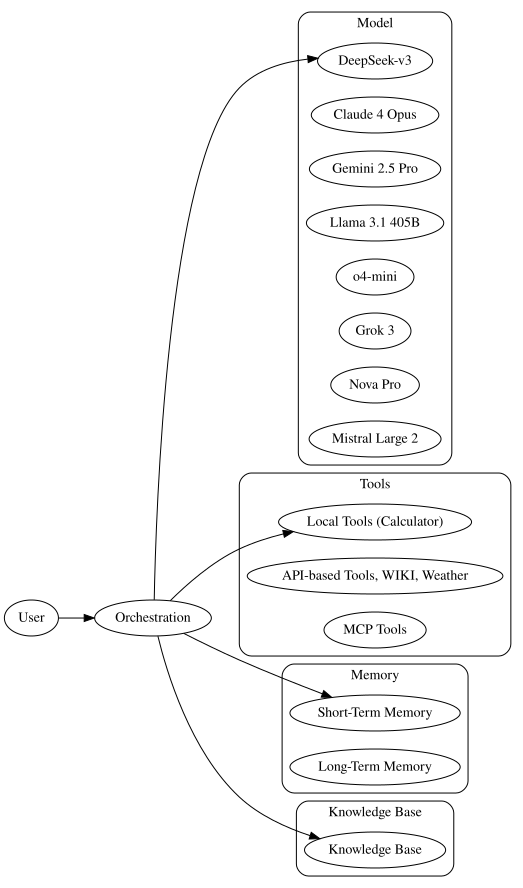

In [ ]:
from graphviz import Digraph

dot = Digraph(comment="Hierarchical Agent Architecture", format="svg")
dot.attr(rankdir="LR")

# Top-level nodes
dot.node("User", "User")
dot.node("Orch", "Orchestration")

# Top-level connections
dot.edge("User", "Orch")

# ===== MODEL CLUSTER =====
with dot.subgraph(name="cluster_model") as c:
    c.attr(label="Model", style="rounded")
    c.node("DeepSeek", "DeepSeek-v3")
    c.node("Claude", "Claude 4 Opus")
    c.node("Gemini", "Gemini 2.5 Pro")
    c.node("Llama", "Llama 3.1 405B")
    c.node("o4", "o4-mini")
    c.node("Grok", "Grok 3")
    c.node("Nova", "Nova Pro")
    c.node("Mistral", "Mistral Large 2")

# ===== TOOLS CLUSTER =====
with dot.subgraph(name="cluster_tools") as c:
    c.attr(label="Tools", style="rounded")
    c.node("LocalTools", "Local Tools (Calculator)")
    c.node("APITools", "API-based Tools, WIKI, Weather")
    c.node("MCPTools", "MCP Tools")

# ===== MEMORY CLUSTER =====
with dot.subgraph(name="cluster_memory") as c:
    c.attr(label="Memory", style="rounded")
    c.node("STM", "Short-Term Memory")
    c.node("LTM", "Long-Term Memory")

# ===== KNOWLEDGE BASE CLUSTER =====
with dot.subgraph(name="cluster_kb") as c:
    c.attr(label="Knowledge Base", style="rounded")
    c.node("KB", "Knowledge Base")

# Orchestration connections (only to top-level clusters)
dot.edge("Orch", "DeepSeek", lhead="cluster_model")
dot.edge("Orch", "LocalTools", lhead="cluster_tools")
dot.edge("Orch", "STM", lhead="cluster_memory")
dot.edge("Orch", "KB", lhead="cluster_kb")

dot


## Hierarchical Agent Architecture

| Level | Component | Contents |
|------|-----------|----------|
| 1 | User | Initiates request |
| 2 | Orchestration | Controls flow, sequencing, and decisions |
| 3 | Model | DeepSeek-v3<br>Claude 4 Opus<br>Gemini 2.5 Pro<br>Llama 3.1 405B<br>o4-mini<br>Grok 3<br>Nova Pro<br>Mistral Large 2 |
| 3 | Tools | Local Tools<br>API-based Tools<br>MCP Tools |
| 3 | Memory | Short-Term Memory<br>Long-Term Memory |
| 3 | Knowledge Base | Documents<br>Vector Store<br>Structured Data |


# 1.2_tools & web search

What separates an Agent from standard chatbot is the <br>
> Its ability to take Action<br>
> See output from those actions<br>
> And React accordingly

<div style="text-align:center">
  <h3>REACT AGENTS</h3>
  <p>Think → Act → Observe</p>
</div>

<br>

The Actions and Agent can take depends on Tools Provided, and Tools can allow an agent to :
 > Access Data<br>
 > Execute Task <br>
 & So on <br>
 Making it more capable System<br>
<br>

Lets make and understand about Tools but making some custom ones



LangChain has a new emphasis on agents with a new ReAct agent. ReAct stands for Reasoning and Acting. ReAct agents operate in a loop. It starts when a model receives a request. <br>

It first reasons about it. It then uses tools to take action. The tools provide observations. At this point, the LLM can reason again, determine if it can respond to the request by producing a final result, or it can take further action and continue the tool calling loop
<br>

ReAct Agent<br>

Synergeging Reasong and Acting in Language Models
- **Reason**
- **Action**
- **Observation**


## 1.2.1. Custom Tools/ Definitions

### Tool definition
> Tool provides the action Part <br><br>
> By Default tool name is same as function name<br><br>
> We can alter that by passing a name `@tool("square_root")`  <br><br>
> Description by default comes from docstring provided in function but we can override that by passing like below<br>
`@tool("square_root", description="Calculate the square root of a number")`

> Tools can help in CRUD: <br>
 Create<br>
 Read<br>
 Update<br>
 Delete (Not recommended)<br>


In [ ]:
from langchain.tools import tool
# A tool decorator converts a function to tool
# By Default tool name is same as function name
@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
# By Default tool name is same as function name
# We can alter that by passing a name
@tool("square_root")
def tool1(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
# Description by default comes from docstring provided in function but we can override that by passing like below
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

In [ ]:
tool1.invoke({"x": 467})

21.61018278497431

In [ ]:
square_root.invoke({"x": 467})

21.61018278497431

In [ ]:
square_root.invoke({"x": "four hundred sixty seven"})

ValidationError: 1 validation error for square_root
x
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='four hundred sixty seven', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/float_parsing

#### We can just add a calculator tool

In [ ]:
from typing import Literal

from langchain.tools import tool

@tool("Calculator", description="Do basic addition, substraction, division , multiplication")
def real_number_calculator(a: float, b: float, operation: Literal["add", "subtract", "multiply", "divide"]) -> float:
    print(" Invoking calculator tool")
    # Perform the specified operation
    if operation == "add":
        return a + b
    elif operation == "subtract":
        return a - b
    elif operation == "multiply":
        return a * b
    elif operation == "divide":
        if b == 0:
            raise ValueError("Division by zero is not allowed.")
        return a / b
    else:
        raise ValueError(f"Invalid operation: {operation}")

### Adding tool to agents

Our tools are ready, lets put them to use

In [ ]:
from langchain.agents import create_agent
agent = create_agent(
    model=model,
    tools=[tool1],
    system_prompt="You are an arithmetic wizard. Use your tools to calculate the square root and square of any number."
)

In [ ]:
from langchain.messages import HumanMessage
question = HumanMessage(content="What is the square root of four hundred sixty seven ?")
response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)

The square root of 467 is approximately 21.61018278497431. 
(rounded: ≈ 21.6102)


In [ ]:
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the square root of four hundred sixty seven ?
================================== Ai Message ==================================
Tool Calls:
  square_root (call_CaEhxZw5qv0iMaH1ZWyX3cl3)
 Call ID: call_CaEhxZw5qv0iMaH1ZWyX3cl3
  Args:
    x: 467
================================= Tool Message =================================
Name: square_root

21.61018278497431
================================== Ai Message ==================================

The square root of 467 is approximately 21.61018278497431. 
(rounded: ≈ 21.6102)


In [ ]:
from langchain.messages import HumanMessage
question = HumanMessage(content="What is the square root of Four hundred sixty seven ?")
response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)

The square root of 467 is approximately 21.61018278497431. (Since it's irrational, this is an approximation.)


In [ ]:
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the square root of -467 ?
================================== Ai Message ==================================
Tool Calls:
  square_root (call_r70szNtdi8FKSDKA8UpGFmyd)
 Call ID: call_r70szNtdi8FKSDKA8UpGFmyd
  Args:
    x: -467
================================= Tool Message =================================
Name: square_root

(1.3232420588304011e-15+21.61018278497431j)
================================== Ai Message ==================================

sqrt(-467) is purely imaginary.

- Exact form: sqrt(-467) = i * sqrt(467)
- Numerically: sqrt(467) ≈ 21.61018278497431, so sqrt(-467) ≈ 21.61018278497431 i
- The two square roots are ±21.61018278497431 i


#### Real Word Detailed Tool Description

In [ ]:
from typing import Literal

from langchain.tools import tool


@tool(
    "calculator",
    parse_docstring=True,
    description=(
        "Perform basic arithmetic operations on two real numbers."
        "Use this whenever you have operations on any numbers, even if they are integers."
    ),
)
def real_number_calculator(
    a: float, b: float, operation: Literal["add", "subtract", "multiply", "divide"]) -> float:
    """Perform basic arithmetic operations on two real numbers.

    Args:
        a (float): The first number.
        b (float): The second number.
        operation (Literal["add", "subtract", "multiply", "divide"]):
            The arithmetic operation to perform.

            - `"add"`: Returns the sum of `a` and `b`.
            - `"subtract"`: Returns the result of `a - b`.
            - `"multiply"`: Returns the product of `a` and `b`.
            - `"divide"`: Returns the result of `a / b`. Raises an error if `b` is zero.

    Returns:
        float: The numerical result of the specified operation.

    Raises:
        ValueError: If an invalid operation is provided or division by zero is attempted.
    """
    print("Invoking calculator tool")
    # Perform the specified operation
    if operation == "add":
        return a + b
    elif operation == "subtract":
        return a - b
    elif operation == "multiply":
        return a * b
    elif operation == "divide":
        if b == 0:
            raise ValueError("Division by zero is not allowed.")
        return a / b
    else:
        raise ValueError(f"Invalid operation: {operation}")

In [ ]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage
agent = create_agent(
    model=model,
    tools=[tool1,real_number_calculator],
    system_prompt="You are an arithmetic wizard. Use your tools to do the maths"
)


question = HumanMessage(content="What is the addition of 3.067 and 7.896 ?")
response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

Invoking calculator tool
The sum is 10.963. (Note: a floating-point result might show a tiny extra digit like 10.963000000000001 due to representation, but the exact sum is 10.963.)
================================ Human Message =================================

What is the addition of 3.067 and 7.896 ?
================================== Ai Message ==================================
Tool Calls:
  calculator (call_OGDNNNTiO0DciCRZEUB1QuFZ)
 Call ID: call_OGDNNNTiO0DciCRZEUB1QuFZ
  Args:
    a: 3.067
    b: 7.896
    operation: add
================================= Tool Message =================================
Name: calculator

10.963000000000001
================================== Ai Message ==================================

The sum is 10.963. (Note: a floating-point result might show a tiny extra digit like 10.963000000000001 due to representation, but the exact sum is 10.963.)


In [ ]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage
agent = create_agent(
    model=model,
    tools=[tool1],
    system_prompt="You are an arithmetic wizard. Use your tools to do the maths"
)


question = HumanMessage(content="What is the addition of 3.067 and 7.896 ?")
response = agent.invoke(
    {"messages": [question]}
)
# print(response['messages'][-1].content)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the addition of 3.067 and 7.896 ?
================================== Ai Message ==================================

10.963


### Lets try without Tool

In [ ]:
from langchain.agents import create_agent

agent_without_tool = create_agent(
    model=model,
    # tools=[tool1],
    system_prompt="You are an arithmetic wizard. Use your tools to calculate the square root and square of any number."
)

from langchain.messages import HumanMessage

question = HumanMessage(content="What is the square root of 467?")

response = agent_without_tool.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

Approximately 21.610183.
================================ Human Message =================================

What is the square root of 467?
================================== Ai Message ==================================

Approximately 21.610183.


# Experiment Zone

In [ ]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

@tool
def square(x: float) -> float:
    """Calculate the square of a number"""
    return x ** 2

In [ ]:
from langchain.agents import create_agent

# create subagents

subagent_1 = create_agent(
    model=model,
    tools=[square_root]
)

subagent_2 = create_agent(
    model=model,
    tools=[square]
)


In [ ]:
from langchain.messages import HumanMessage

@tool
def call_subagent_1(x: float) -> float:
    """Call subagent 1 in order to calculate the square of a number"""
    response = subagent_1.invoke({"messages": [HumanMessage(content=f"Calculate the square root of {x}")]})
    return response["messages"][-1].content

@tool
def call_subagent_2(x: float) -> float:
    """Call subagent 2 in order to calculate the square root of a number"""
    response = subagent_2.invoke({"messages": [HumanMessage(content=f"Calculate the square of {x}")]})
    return response["messages"][-1].content

## Creating the main agent

main_agent = create_agent(
    model=model,
    tools=[call_subagent_1, call_subagent_2],
    system_prompt="You are a helpful assistant who can call subagents to calculate the square root or square of a number.")

In [ ]:
question = "What is the square root of 456?"

response = main_agent.invoke({"messages": [HumanMessage(content=question)]})
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What is the square root of 456?
================================== Ai Message ==================================
Tool Calls:
  call_subagent_2 (call_cMFaqwjdteeVP2x9bb7ltG2G)
 Call ID: call_cMFaqwjdteeVP2x9bb7ltG2G
  Args:
    x: 456
================================= Tool Message =================================
Name: call_subagent_2

The square of 456.0 is 207936.0.
================================== Ai Message ==================================

The square root of 456 is approximately 21.3542 (exactly sqrt(456) = 2 * sqrt(114)). The previous tool response gave the square instead of the root.


## 1.2.2. Search Tools : Web Search

### Without web search

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=model
)

In [ ]:
from langchain.messages import HumanMessage
# this will consfidently tell me mayor per knowledge cutoff
question = HumanMessage(content="Who is the current mayor of San Francisco?")

response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)

London Breed.

As of my last update (June 2024), she is the mayor of San Francisco. She became mayor in 2018 (after a special election to complete Ed Lee’s term) and was reelected in 2022, with her current term starting in 2023. For the very latest status, you can check the City and County of San Francisco official website or a reliable news source. Would you like a brief bio or key initiatives from her administration?


In [ ]:
# Lets see the knowledge cutoff
from langchain.messages import HumanMessage

question = HumanMessage(content="How up to date is your training knowledge?")

response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)

My training data goes up to June 2024. I don’t have real-time data or updates after that unless you provide new information or I’m using a browser tool (if enabled in your setup). 

If you need current details, I can help in two ways:
- Use a browser tool (if available) to fetch recent sources.
- You provide articles or facts, and I’ll summarize or analyze them. 

I can still assist with background, concepts, and reasoning on newer topics by applying general knowledge and patterns.


### Add web search tool

In [ ]:
pip install tavily

  Preparing metadata (setup.py) ... done
  Created wheel for tavily: filename=tavily-1.1.0-py3-none-any.whl size=6186 sha256=69566f6388e46e947d5b65921cf42e0842de7f96acfaf07a47ee71a37b3853c4
  Stored in directory: /root/.cache/pip/wheels/df/60/d8/883106a49d84c6a06cf0690728f44bca27a214ce10c628e28d
Successfully built tavily


In [ ]:
from google.colab import userdata
TAVILY_API_KEY=userdata.get('tavily_key')

In [ ]:
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient

tavily_client = TavilyClient(TAVILY_API_KEY)

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""
    print(tavily_client.search(query))
    return tavily_client.search(query)

web_search.invoke("Who is the current mayor of San Francisco?")

agent = create_agent(
    model=model,
    tools=[web_search]
)

question = HumanMessage(content="Who is the current mayor of San Francisco?")

response = agent.invoke(
    {"messages": [question]}
)

from pprint import pprint

# pprint(response['messages'])

for i, msg in enumerate(response['messages']):
    msg.pretty_print()

{'query': 'Who is the current mayor of San Francisco?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://ballotpedia.org/Daniel_Lurie', 'title': 'Daniel Lurie', 'content': "#### Sign up to receive Ballotpedia's daily newsletter\n\nEmail \\\n\nFirst Name\n\nPlease complete the Captcha above\n\n#### Ballotpedia on Facebook\n\nShare this page\n\nFollow Ballotpedia\n\n#### Ballotpedia on Twitter\n\nShare this page\n\nFollow Ballotpedia\n\nBallotpedia Logo\nBallotpedia Logo\n\n# Daniel Lurie\n\nSilhouette Placeholder Image.png\n\nReport an officeholder change\n\nDaniel Lurie is the mayor of San Francisco, California. He assumed office on January 8, 2025. His current term ends on January 8, 2029. [...] ## Footnotes\n\n| Political offices | | |\n --- \n| Preceded by   London Breed | Mayor of San Francisco   2025-Present | Succeeded by   - |\n\n|  |  |  |  |  |  |  |  |  |  |\n ---  ---  ---  ---  --- |\n| | v • e 2024 Municipal Elections | | |  ---  |  |

### Alternate Approaches: Hack: Use the Latest Model

### https://platform.openai.com/docs/models/compare

https://openai.com/api/pricing/


Core OpenAI Chat / Reasoning Models

gpt-5.2 – state-of-the-art general and agentic reasoning model. Best for complex tasks & code.
OpenAI Platform
+1

gpt-5.2-pro – higher-precision version of GPT-5.2 for hardest problems.
OpenAI Platform

gpt-5.1 – previous flagship general-purpose model.
OpenAI Platform

gpt-5 – earlier GPT-5 family model.
OpenAI Platform

gpt-4.1 – strong instruction-following & tool-use model with long context support.
OpenAI Platform

Smaller / Cost-Efficient Variants

gpt-5-mini – balance between capability and cost.
OpenAI Platform

gpt-5-nano – fastest and most cost-efficient within GPT-5 line.
OpenAI Platform

gpt-4.1-mini / gpt-4.1-nano – smaller variants of GPT-4.1 for cheaper use.
OpenAI

Specialized & Other Models

gpt-5.1-codex-max / GPT-5.2-Codex variants – optimized for coding workflows.
OpenAI Platform
+1

Image / multimodal (for image generation or combined tasks):

gpt-image-1.5, chatgpt-image-latest – image models.
OpenAI Platform

Embeddings & Non-Chat Models (if needed later)

These aren’t chat models but are available via the API:

text-embedding-3-large, text-embedding-3-small for embeddings.

In [ ]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

model_l = init_chat_model(model="gpt-5.2",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)
agent = create_agent(
    model=model_l
)


from langchain.messages import HumanMessage

question = HumanMessage(content="How up to date is your training knowledge?")

response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)


from langchain.messages import HumanMessage

question = HumanMessage(content="Who is the current mayor of San Francisco?")

response = agent.invoke(
    {"messages": [question]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

My built-in training knowledge has a cutoff of **August 2025**. That means I may not reliably know about events, releases, research, or changes that happened after that date.

If you tell me what topic you’re asking about (or share links/text), I can still help by:
- reasoning from general principles,
- analyzing or summarizing what you provide,
- and, if you want, suggesting how to verify the most current info.
================================ Human Message =================================

Who is the current mayor of San Francisco?
================================== Ai Message ==================================

As of March 2025, the mayor of San Francisco is **Daniel Lurie**, who took office on **January 8, 2025**.


Tools allow agents to 'Act' in the real world. Careful descriptions can help your agent discover how to use your tools.

LangChain supports many tool formats and tool sets. Here we covered some common cases, but check the docs for more information.

https://docs.langchain.com/oss/python/langchain/tools

# 1.3_memory & Run Time Context
### A pretty basic feature we expect from a chatbot is to memorize conversations while we are having it.

### 1.3.1. No memory
#### So far our agents don't have memory enabled by default: Lets check it here

In [ ]:
from langchain.agents import create_agent
agent = create_agent(
    model = model
)

In [ ]:
from langchain.messages import HumanMessage
from pprint import pprint
question = HumanMessage(content="Hello my name is Vinay and my favourite colour is Orange")
response = agent.invoke(
    {"messages": [question]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

Hello my name is Vinay and my favourite colour is Orange
================================== Ai Message ==================================

Hi Vinay! Nice to meet you. Orange is a vibrant, energetic color.

What would you like to do today? Here are a few ideas:
- Learn about orange: symbolism, culture, and vibes
- Get orange-themed ideas for fashion, home décor, or branding
- Find orange-inspired recipes or flavor pairings
- Help with any other question or project you have

Tell me what you’re in the mood for, and we’ll dive in.


In [ ]:
# Observe it don't remember it by default
question = HumanMessage(content="What's my favourite colour?")
response = agent.invoke(
    {"messages": [question]}
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

What's my favourite colour?
================================== Ai Message ==================================

I don’t know your favorite color yet. I don’t have access to your personal preferences.

If you’d like, we can figure it out fast:
- Quick guess: blue is a common favorite—want me to go with that?
- Or answer a couple of tiny prompts and I’ll suggest one tailored to you:
  1) Do you prefer cool colors (blue/green/purple) or warm colors (red/orange/yellow)?
  2) Do you like bright, bold colors or soft, muted tones?


### 1.3.2. Memory
#### Retain Information over chat session
#### Agents need memory along with reasoning



In [ ]:
# We can enable agents to have Memory with checkpointer and InMemorySaver
from langgraph.checkpoint.memory import InMemorySaver
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
)

In [ ]:
from langchain.messages import HumanMessage
question = HumanMessage(content="Hello my name is Vinay and my favourite colour is Orange")
config = {"configurable": {"thread_id": "1"}} # Each thread id maintains unique conversation
response = agent.invoke(
    {"messages": [question]},
    config,
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

Hello my name is Vinay and my favourite colour is Orange
================================== Ai Message ==================================

Nice to meet you, Vinay! Orange is a vibrant, energetic color—great choice. What would you like to do today? I can help with orange-inspired outfits, home decor ideas, color palettes, or just chat about something else.


In [ ]:
# So now we have Agents with memory
question = HumanMessage(content="What's my favourite colour?")
response = agent.invoke(
    {"messages": [question]},
    config,
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

================================ Human Message =================================

Hello my name is Vinay and my favourite colour is Orange
================================== Ai Message ==================================

Nice to meet you, Vinay! Orange is a vibrant, energetic color—great choice. What would you like to do today? I can help with orange-inspired outfits, home decor ideas, color palettes, or just chat about something else.
================================ Human Message =================================

What's my favourite colour?
================================== Ai Message ==================================

Your favourite colour is orange. Want some orange-inspired ideas for outfits, decor, or palettes?


### 1.3.3. No runtime_context
#### What if agent should know certain context
{ 'role': 'internal'}


In [ ]:
from dataclasses import dataclass
@dataclass
class ColourContext:
    favourite_colour: str = "orange"
    least_favourite_colour: str = "yellow"

In [ ]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from pprint import pprint
agent = create_agent(
    model=model,
    context_schema=ColourContext # Even when we configure like this it is not passed
)
response = agent.invoke(
    {"messages": [HumanMessage(content="What is my favourite colour?")]},
    context=ColourContext()
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()
# Even when we passed the context it couldn't access it directly. It can access via Tool Call

================================ Human Message =================================

What is my favourite colour?
================================== Ai Message ==================================

I don’t know your favourite colour unless you tell me. If you’d like, we can figure it out quickly.

Options:
- Tell me a few clues (cool vs warm colors, bright vs muted, any you dislike), and I’ll guess.
- Or answer this mini-quiz:
  1) Do you prefer cool colors (blue/green/purple) or warm colors (red/orange/yellow)?
  2) Do you like bright/saturated colors or pastel/muted tones?
  3) Do you want something bold or calm?
  4) Is there a color you currently find yourself drawn to?

Based on your answers, I’ll suggest your likely favorite and a couple close alternatives. If you just want a quick guess, blue is a common favourite. Want to start with one of the options above?


### 1.3.4. With Runtime Context: Show ChatGPT Preference: Micro Fine Tunnig

In [ ]:
from langchain.tools import tool, ToolRuntime

# Tool Call can access that context however
@tool
def get_favourite_colour(runtime: ToolRuntime) -> str:
    """Get the favourite colour of the user"""
    return runtime.context.favourite_colour # This way it can access

@tool
def get_least_favourite_colour(runtime: ToolRuntime) -> str:
    """Get the least favourite colour of the user"""
    return runtime.context.least_favourite_colour # This way it can access

In [ ]:
agent = create_agent(
    model=model,
    tools=[get_favourite_colour, get_least_favourite_colour],
    context_schema=ColourContext
)

response = agent.invoke(
    {"messages": [HumanMessage(content="What is my favourite colour?")]},
    context=ColourContext()
)

for i, msg in enumerate(response['messages']):
    msg.pretty_print()

/usr/local/lib/python3.12/dist-packages/pydantic/functional_validators.py:839: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='context', input_value=ColourContext(favourite_c...vourite_colour='yellow'), input_type=ColourContext])
  function=lambda v, h: h(v), schema=original_schema
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='context', input_value=ColourContext(favourite_c...vourite_colour='yellow'), input_type=ColourContext])
  return self.__pydantic_serializer__.to_python(


================================ Human Message =================================

What is my favourite colour?
================================== Ai Message ==================================
Tool Calls:
  get_favourite_colour (call_1hPA1jFBguhyP1vWxImQPp5z)
 Call ID: call_1hPA1jFBguhyP1vWxImQPp5z
  Args:
================================= Tool Message =================================
Name: get_favourite_colour

orange
================================== Ai Message ==================================

Your favourite colour is orange.

Would you like me to tell you your least favourite colour as well?


In [ ]:
response = agent.invoke(
    {"messages": [HumanMessage(content="What is my favourite colour?")]},
    context=ColourContext(favourite_colour="green")
)
for i, msg in enumerate(response['messages']):
    msg.pretty_print()

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='context', input_value=ColourContext(favourite_c...vourite_colour='yellow'), input_type=ColourContext])
  return self.__pydantic_serializer__.to_python(


================================ Human Message =================================

What is my favourite colour?
================================== Ai Message ==================================
Tool Calls:
  get_favourite_colour (call_YW1gTfd1LReXc1yrmvxyoCQa)
 Call ID: call_YW1gTfd1LReXc1yrmvxyoCQa
  Args:
================================= Tool Message =================================
Name: get_favourite_colour

green
================================== Ai Message ==================================

Your favourite colour is green. Would you like to change it or use this for anything else?


Limitatations of Context: Its Immutable what if during execution if someone enters spanish text and ask questions in spanish, Agents on its own shall be able to detect and adapt.

With Context it can detect but cannot adapt:update as its immutable

Solution: Use State

### 1.3.5. Without State

In [ ]:
from langchain.agents import AgentState
# Keep Track of the colour
class CustomState(AgentState):
    favourite_colour: str

In [ ]:
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command
from langchain.messages import ToolMessage

# Let agent update its state on its own using tool , agent can acces the tool at runtime to update
@tool
def update_favourite_colour(favourite_colour: str, runtime: ToolRuntime) -> Command:
    """Update the favourite colour of the user in the state once they've revealed it."""
    return Command(update={
        "favourite_colour": favourite_colour,
        "messages": [ToolMessage("Successfully updated favourite colour", tool_call_id=runtime.tool_call_id)]}
        )


In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model=model,
    tools=[update_favourite_colour],
    checkpointer=InMemorySaver(),
    state_schema=CustomState
)

In [ ]:
from langchain.messages import HumanMessage

response = agent.invoke(
    { "messages": [HumanMessage(content="My favourite colour is green")]},
    {"configurable": {"thread_id": "1"}}
)

In [ ]:
from pprint import pprint

pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='My favourite colour is green', additional_kwargs={}, response_metadata={}, id='e0d1b8ae-89a0-46a6-90f8-af66aa189f58'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 411, 'prompt_tokens': 141, 'total_tokens': 552, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlXUSIcSzxDfQOl6a3q9RVLQxtnqp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7d87-f93b-7b43-a2e2-4905dd8656a7-0', tool_calls=[{'name': 'update_favourite_colour', 'args': {'favourite_colour': 'green'}, 'id': 'call_12FrM6zZ9lccJJnPNw12K0AR', 'type': 'tool_call'}], invalid_

In [ ]:
response = agent.invoke(
    {
        "messages": [HumanMessage(content="Hello, how are you?")],
        "favourite_colour": "green"
    },
    {"configurable": {"thread_id": "10"}}
)

pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e787f7b4-2005-420e-8b12-60ec90a54522'),
              AIMessage(content='Hi there! I’m here and ready to help. Since I’m an AI, I don’t have feelings, but I’m functioning well. What would you like to talk about or do today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 433, 'prompt_tokens': 142, 'total_tokens': 575, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlXV2f59WlQ10RZilWRbYA6VgDICk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7d88-8689-7cc2-a049-00e754c85cfd-0', tool_calls=[], invalid

### 1.3.6. With State

In [ ]:
@tool
def read_favourite_colour(runtime: ToolRuntime) -> str:
    """Read the favourite colour of the user from the state."""
    try:
        return runtime.state["favourite_colour"]
    except KeyError:
        return "No favourite colour found in state"

agent = create_agent(
    model=model,
    tools=[update_favourite_colour, read_favourite_colour],
    checkpointer=InMemorySaver(),
    state_schema=CustomState
)

In [ ]:
response = agent.invoke(
    { "messages": [HumanMessage(content="My favourite colour is green")]},
    {"configurable": {"thread_id": "1"}}
)
pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='My favourite colour is green', additional_kwargs={}, response_metadata={}, id='0365f48f-4c18-4fa1-9937-cbb1b51ea103'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 347, 'prompt_tokens': 162, 'total_tokens': 509, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlXYB3tKRy2C4c41LRooLa6iXmz37', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7d8b-7f69-7c32-ad1b-998b0d590400-0', tool_calls=[{'name': 'update_favourite_colour', 'args': {'favourite_colour': 'green'}, 'id': 'call_mqfq8DLP0OoUSqwl9q1Lgjxn', 'type': 'tool_call'}], invalid_

In [ ]:
response = agent.invoke(
    { "messages": [HumanMessage(content="What's my favourite colour?")]},
    {"configurable": {"thread_id": "1"}}
)
pprint(response)

{'favourite_colour': 'green',
 'messages': [HumanMessage(content='My favourite colour is green', additional_kwargs={}, response_metadata={}, id='0365f48f-4c18-4fa1-9937-cbb1b51ea103'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 347, 'prompt_tokens': 162, 'total_tokens': 509, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlXYB3tKRy2C4c41LRooLa6iXmz37', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7d8b-7f69-7c32-ad1b-998b0d590400-0', tool_calls=[{'name': 'update_favourite_colour', 'args': {'favourite_colour': 'green'}, 'id': 'call_mqfq8DLP0OoUSqwl9q1Lgjxn', 'type': 'tool_call'}], invalid_

# 1.4_multimodal_messages
#### We can provide other Signals like Image, Audio, Video etc.




In [ ]:
# Check Which model is in reference or use
model

ChatOpenAI(profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7acebf45bce0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7acebf4c4b00>, root_client=<openai.OpenAI object at 0x7acec02a3500>, root_async_client=<openai.AsyncOpenAI object at 0x7acebf45b500>, model_name='gpt-5-nano', model_kwargs={}, openai_api_key=SecretStr('**********')

In [ ]:
profile = model.profile

clusters = {
    "INPUT_MODALITIES": {
        "text": profile.get("text_inputs"),
        "image": profile.get("image_inputs"),
        "audio": profile.get("audio_inputs"),
        "video": profile.get("video_inputs"),
        "pdf": profile.get("pdf_inputs"),
        "image_url": profile.get("image_url_inputs"),
    },

    "OUTPUT_MODALITIES": {
        "text": profile.get("text_outputs"),
        "image": profile.get("image_outputs"),
        "audio": profile.get("audio_outputs"),
        "video": profile.get("video_outputs"),
    },

    "AGENT_CAPABILITIES": {
        "reasoning": profile.get("reasoning_output"),
        "tool_calling": profile.get("tool_calling"),
        "structured_output": profile.get("structured_output"),
        "tool_choice": profile.get("tool_choice"),
    }
}


for category, values in clusters.items():

    supported = [k for k,v in values.items() if v]
    not_supported = [k for k,v in values.items() if not v]

    print("\n" + "="*50)
    print(category)
    print("="*50)

    print("\nSUPPORTED")
    print("-"*30)
    for item in supported:
        print("•", item)

    print("\nNOT SUPPORTED")
    print("-"*30)
    for item in not_supported:
        print("•", item)


print("\n" + "="*50)
print("LIMITS")
print("="*50)
print("max_input_tokens  :", profile["max_input_tokens"])
print("max_output_tokens :", profile["max_output_tokens"])


INPUT_MODALITIES

SUPPORTED
------------------------------
• text
• image
• pdf
• image_url

NOT SUPPORTED
------------------------------
• audio
• video

OUTPUT_MODALITIES

SUPPORTED
------------------------------
• text

NOT SUPPORTED
------------------------------
• image
• audio
• video

AGENT_CAPABILITIES

SUPPORTED
------------------------------
• reasoning
• tool_calling
• structured_output
• tool_choice

NOT SUPPORTED
------------------------------

LIMITS
max_input_tokens  : 272000
max_output_tokens : 128000


### Text input

In [ ]:
from langchain.agents import create_agent
agent = create_agent(
    model=model,
    system_prompt="You are a science fiction writer, create a capital city at the users request.",
)

In [ ]:
from langchain.messages import HumanMessage
question = HumanMessage(content=[
    {"type": "text", "text": "What is the capital of The Moon?"}
])
response = agent.invoke(
    {"messages": [question]}
)
print(response['messages'][-1].content)

In this sci‑fi setting, the Moon is a sovereign polity called the Lunar Union, and its capital is Lunaris Prime.

Lunaris Prime sits on the rim of a shielded crater on the Moon’s near side, ringed by solar domes and a gravity-stabilized transit ring. It’s the political heart of the Union, housing the Crescent Citadel—the seat of government—and vast archives stored in crystalline vaults. The city blends glass, basalt, and luminous fiber-optic canopies, with tunnels winding beneath the crater floor to water-ice reservoirs and research labs. It’s both a political center and a cultural crossroads for lunar settlers and Earth arrivals.

Want a different vibe or era (corporate capital, rebellious habitat, ancient ruins, etc.)? I can tailor Lunaris Prime to your taste.


### Image Input

In [ ]:
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(accept='.png', multiple=False)
display(uploader)

FileUpload(value={}, accept='.png', description='Upload')

In [ ]:
print(uploader.value)

{'Screenshot 2026-05-31 at 4.01.17\u202fPM.png': {'metadata': {'name': 'Screenshot 2026-05-31 at 4.01.17\u202fPM.png', 'type': 'image/png', 'size': 175849, 'lastModified': 1780223482597}, 'content': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01a\x00\x00\x00\xec\x08\x06\x00\x00\x00\xa5\xa6\x17e\x00\x00\x01[iCCPICC Profile\x00\x00(\x91m\x90\xbdK\xc3P\x14\xc5O5\xa5P?P\xe8$\x82qRK\x15M\xc5\x8fE\xa8ET\x10\x0cU\xd1\xba\xa5IM\xabi|\xa4\x11\xf5/pq\xae\xab\x93\xff\x80B\x17\x07\xc7\xe2*hq\xd5I\x10\x04!\x08\x1a\xe2}\xad\x9aV\xbdp\xb9?\x0e\xe7\xbdw\xdf\x01Z\x04\x851C\x00P0m+5?+n\xa47\xc5\xd0\x13\x82\xe8C\x07\xa6\x11Q\xd4"K\xc8\xf2\x12Y\xf0=\x9b\xcb\xb9E\x80\xcf\x9ba~\x97;\xb5\xec\xbe\xf4\x94\xfa\xab\x0fc\xcf\x15\xe1\xed\xfc\xaf\xbf\xa9\xc2Z\xb6\xa8\xd2\xfc\xa0\x8e\xaa\xcc\xb2\x81\xc0 \xb1\xbco3\xce\x07\xc4\x11\x8b\x96">\xe6\xac\xd7\xf9\x94s\xa6\xce\x175\xcfj*I\\!\xeeRs\x8aF\\%\x8ee\x1at\xbd\x81\x0b\xc6\x9e\xfa\xb5\x03\xdf\xbe=k\xae\xad\xd0\xec\xa4\xee\xc5\x02d\x88\x98\x83\x84I\xc4)\x9b\xff\xbd

In [ ]:
import base64

# Get the first (and only) uploaded file dict
uploaded_file = list(uploader.value.values())[0]

# This is a memoryview
content_mv = uploaded_file["content"]

# Convert memoryview -> bytes
img_bytes = bytes(content_mv)  # or content_mv.tobytes()

# Now base64 encode
img_b64 = base64.b64encode(img_bytes).decode("utf-8")

In [ ]:
img_b64

'...'

In [ ]:
multimodal_question = HumanMessage(content=[
    {"type": "text", "text": "Tell me about this file what do you see"},
    {"type": "image", "base64": img_b64, "mime_type": "image/png"}
])

response = agent.invoke(
    {"messages": [multimodal_question]}
)

print(response['messages'][-1].content)

What I see in the image:
- A bright, fiery sun dominates the right side, casting a warm glow across the scene.
- A string of planets arcs across the frame, some with rings, giving a sense of a compact, stylized solar system.
- White curved lines trace the planets’ orbits, emphasizing motion and gravitational order.
- A deep, star-filled backdrop with hints of a blue nebula or cosmic dust on the left, adding depth and contrast.
- The overall vibe is cinematic and schematic—a design that feels both artistic and scientifically plausible.

If you’d like, I can turn this scene into a capital-city concept inspired by it. Here’s one idea to start:

Capital city concept: The Crown of Helios (Sol Crown)
- Location and form: A vast orbital megacity ringed around the inner solar system, anchored to the star’s energy along multiple orbital tracks. The structure resembles a luminous crown—a web of arches, rings, and solar-sail-like façades that skim the heat and light of the sun while staying cool 

# Project 1: Personal Chef

### We are going to use leftover food at home and use Personal Chef to search online and get receipe suggestion.

In [ ]:
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient

# Search for Receipe, LLM will search for latest receipe and make use of those
tavily_client = TavilyClient(TAVILY_API_KEY)

@tool
def web_search(query: str) -> Dict[str, Any]:
    """Search the web for information"""
    return tavily_client.search(query)

In [ ]:
# Agent Role and Work
system_prompt = """

You are a personal chef. The user will give you a list of ingredients they have left over in their house.

Using the web search tool, search the web for recipes that can be made with the ingredients they have.

Return recipe suggestions and eventually the recipe instructions to the user, if requested.

"""

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
agent = create_agent(
    model=model,
    tools=[web_search],
    system_prompt=system_prompt,
    checkpointer=InMemorySaver()
)

In [ ]:
from langchain.messages import HumanMessage
config = {"configurable": {"thread_id": "1"}}
response = agent.invoke(
    {"messages": [HumanMessage(content="I have some leftover rajma and rice. What can I make?")]},
    config
)
print(response['messages'][-1].content)

Awesome idea—rajma (kidney beans) and rice are a perfect pairing. Here are a few recipe ideas you can make with those leftovers, with quick descriptions and links to fuller instructions:

- Rajma fried rice
  - Quick, one-pan dish: sauté aromatics, toss in cooked rajma, then mix in the rice. Finish with a splash of soy or Indian spices for flavor.
  - Source link: https://foodfoodonlyfood.wordpress.com/2016/10/03/rajma-fried-rice-fried-rice-with-red-kidney-beans-recipe

- Rajma pulao (rajma rice pilaf)
  - Fragrant, one-pot rice cooked with rajma and spices. You can adapt the method to use leftover rice by just warming it with the beans and seasoning.
  - Source link: https://www.vegrecipesofindia.com/rajma-pulao-recipe

- Rajma chawal (classic rajma with rice)
  - A comforting North Indian classic: warm up the rajma curry and serve over plain rice (or mix the curry with the rice for a hearty bowl). Great if you have a few pantry staples like onion, tomato, and spices.
  - Source link:

In [ ]:
from pprint import pprint
pprint(response)
# These are better with Langsmith to trace the steps

{'messages': [HumanMessage(content='I have some leftover rajma and rice. What can I make?', additional_kwargs={}, response_metadata={}, id='91ba65ff-18ac-4191-b537-269e6018fa38'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 655, 'prompt_tokens': 200, 'total_tokens': 855, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlY0ATLT7MRcQxGwDp4ZX3spCW4UV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7da5-faf9-7dd3-97ff-97ca2141947f-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'rajma fried rice recipe'}, 'id': 'call_sZZjBUhUPbmOhyQhzno0cieh', 'type': 'tool_call'}, {'name': 'web_search

### Project: Can you upload your fridge inside photo or food phoot and let it decide whats leftover and then suggest you some interesting receipe?

# Module 2: : Get Application Ready

## 2.1_mcp : Lets Find Flight Details

#### Agents Need Runtime Context for example if user like speaking in English or Spannish
#### Are they in Conscise mode or Brainstorming Mode?


## What is MCP?




> An Open Protocol that standadizes how your LLM applications connects to and work with tools and data sources.

> Analogy: Salary

> https://modelcontextprotocol.io/docs/getting-started/intro

> https://github.com/punkpeye/awesome-mcp-servers

> https://glama.ai/mcp/servers?query=

> https://mcp.so/

> https://mcp.so/servers

> https://mcp.so/server/kiwi-travel-mcp/Vytautas%20Dargis

Imagine calling API without keys and without proper Query Language, Without proper Format, Just Using Natural Language

In [ ]:
!pip install langchain_mcp_adapters

In [ ]:
model

ChatOpenAI(profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7acebf45bce0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7acebf4c4b00>, root_client=<openai.OpenAI object at 0x7acec02a3500>, root_async_client=<openai.AsyncOpenAI object at 0x7acebf45b500>, model_name='gpt-5-nano', model_kwargs={}, openai_api_key=SecretStr('**********')

In [ ]:
# Beauty is we don't even need API Key here
from langchain_mcp_adapters.client import MultiServerMCPClient
# https://mcp.so/server/kiwi-travel-mcp/Vytautas%20Dargis
client = MultiServerMCPClient(
    {
        "travel_server": {
                "transport": "streamable_http",
                "url": "https://mcp.kiwi.com"
            }
    }
)

tools = await client.get_tools()


In [ ]:
tools

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model= model,
    tools=tools,
    checkpointer=InMemorySaver(),
    system_prompt="You are a travel agent. No follow up questions."
)

In [ ]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = await agent.ainvoke(
    {"messages": [HumanMessage(content="Get me a flight from Bengaluru to Delhi on 03/06/2026")]},
    config
    )

In [ ]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='Get me a flight from Bengaluru to Delhi on 03/06/2026', additional_kwargs={}, response_metadata={}, id='912e4f3c-b177-4185-bdc8-c919aac20fe3'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 362, 'prompt_tokens': 1230, 'total_tokens': 1592, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlY6kHAYW3l8yGmVW8MC82vkvWVfw', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7dac-3446-7343-838b-5d81e2dfed4f-0', tool_calls=[{'name': 'search-flight', 'args': {'flyFrom': 'Bengaluru', 'flyTo': 'Delhi', 'departureDate': '03/06/2026'}, 'id': 'call_V2t8TThzpNznikC99iM0zCHQ', 

In [ ]:
print(response["messages"][-1].content)

Here are good Bengaluru (BLR) to Delhi (DEL) flight options for 03/06/2026. I’ve grouped them by the lowest price first, then the shortest duration, then other notable picks.

Cheapest flights (78 EUR)
- BLR → DEL | 03/06 03:55 → 07:00 (3h 5m) | Economy | Price: 78 EUR | Deep link: https://on.kiwi.com/TQvVg4
- BLR → DEL | 03/06 05:00 → 07:50 (2h 50m) | Economy | Price: 78 EUR | Deep link: https://on.kiwi.com/8yNpPc
- BLR → DEL | 03/06 05:25 → 08:25 (3h 0m) | Economy | Price: 78 EUR | Deep link: https://on.kiwi.com/IOVuhC
- BLR → DEL | 03/06 05:50 → 08:50 (3h 0m) | Economy | Price: 78 EUR | Deep link: https://on.kiwi.com/sh6lxs
- BLR → DEL | 03/06 18:25 → 21:30 (3h 5m) | Economy | Price: 78 EUR | Deep link: https://on.kiwi.com/aximOL

Shortest duration flight (2h 30m)
- BLR → DEL | 03/06 14:15 → 16:45 (2h 30m) | Economy | Price: 88 EUR | Deep link: https://on.kiwi.com/OOejQ0

Other notable options
- BLR → DEL | 03/06 05:25 → 08:25 (3h 0m) | Economy | Price: 87 EUR | Deep link: https://o

## 2.2 SubAgents/ MultiAgents





> Agent Performace

> Should we offer all work to be done By CEO or CXO?

> Asking one agent to do everything is like asking the CEO to write code, negotiate salaries, run ads, and approve invoices — output exists, but excellence disappears.

> Their Quality of Output will suffer as anyone can only handle limited Context: Context Saturation, Loss of Domain/Execution Depth

> Multiagents could handle it with breakdown and interdepartment conflict free way.

In [ ]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

@tool
def square(x: float) -> float:
    """Calculate the square of a number"""
    return x ** 2

In [ ]:
from langchain.agents import create_agent

# create subagents

subagent_1 = create_agent(
    model=model,
    tools=[square_root]
)

subagent_2 = create_agent(
    model=model,
    tools=[square]
)


In [ ]:
from langchain.messages import HumanMessage

@tool
def call_subagent_1(x: float) -> float:
    """Call subagent 1 in order to calculate the square root of a number"""
    response = subagent_1.invoke({"messages": [HumanMessage(content=f"Calculate the square root of {x}")]})
    return response["messages"][-1].content

@tool
def call_subagent_2(x: float) -> float:
    """Call subagent 2 in order to calculate the square of a number"""
    response = subagent_2.invoke({"messages": [HumanMessage(content=f"Calculate the square of {x}")]})
    return response["messages"][-1].content

## Creating the main agent

main_agent = create_agent(
    model=model,
    tools=[call_subagent_1, call_subagent_2],
    system_prompt="You are a helpful assistant who can call subagents to calculate the square root or square of a number.")

In [ ]:
question = "What is the square root of 456?"

response = main_agent.invoke({"messages": [HumanMessage(content=question)]})

In [ ]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='What is the square root of 456?', additional_kwargs={}, response_metadata={}, id='7cb77740-f463-45f5-9602-950c29d00ee0'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2266, 'prompt_tokens': 202, 'total_tokens': 2468, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 2240, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Cv3DvJvBsQCQDxN0sqbRxzmxGu81H', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b93e9-ac4a-78c2-ae8f-2ced304dcf80-0', tool_calls=[{'name': 'call_subagent_1', 'args': {'x': 456}, 'id': 'call_Kay0foq4raq5liFG5Gjri3d6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 202,

## 2.3 wedding_planners

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "travel_server": {
                "transport": "streamable_http",
                "url": "https://mcp.kiwi.com"
            }
    }
)

tools = await client.get_tools()

In [ ]:
from typing import Dict, Any
from tavily import TavilyClient
from langchain.tools import tool

tavily_client = TavilyClient(TAVILY_API_KEY)

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)

In [ ]:
!pip install langchain_community

In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
import os
print(os.path.exists("resources"))

False


In [ ]:
os.makedirs("resources", exist_ok=True)

In [ ]:
import os
print(os.listdir("resources"))

[]


In [ ]:
import os, sqlite3

db_path = os.path.abspath("resources/Chinook.db")
print("DB PATH:", db_path)

conn = sqlite3.connect(db_path)
print("Connection successful")
conn.close()


DB PATH: /content/resources/Chinook.db
Connection successful


In [ ]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///resources/Chinook.db")

@tool
def query_playlist_db(query: str) -> str:

    """Query the database for playlist information"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error querying database: {e}"

/tmp/ipykernel_644/2549610831.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


In [ ]:
# Create State
from langchain.agents import AgentState

class WeddingState(AgentState):
    origin: str
    destination: str
    guest_count: str
    genre: str

In [ ]:
from langchain.agents import create_agent

# Travel agent
travel_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="""
    You are a travel agent. Search for flights to the desired destination wedding location.
    You are not allowed to ask any more follow up questions, you must find the best flight options based on the following criteria:
    - Price (lowest, economy class)
    - Duration (shortest)
    - Date (time of year which you believe is best for a wedding at this location)
    To make things easy, only look for one ticket, one way.
    You may need to make multiple searches to iteratively find the best options.
    You will be given no extra information, only the origin and destination. It is your job to think critically about the best options.
    Once you have found the best options, let the user know your shortlist of options.
    """
)

In [ ]:
# Venue agent
venue_agent = create_agent(
    model=model,
    tools=[web_search],
    system_prompt="""
    You are a venue specialist. Search for venues in the desired location, and with the desired capacity.
    You are not allowed to ask any more follow up questions, you must find the best venue options based on the following criteria:
    - Price (lowest)
    - Capacity (exact match)
    - Reviews (highest)
    You may need to make multiple searches to iteratively find the best options.
    """
)

In [ ]:
# Playlist agent
playlist_agent = create_agent(
    model=model,
    tools=[query_playlist_db],
    system_prompt="""
    You are a playlist specialist. Query the sql database and curate the perfect playlist for a wedding given a genre.
    Once you have your playlist, calculate the total duration and cost of the playlist, each song has an associated price.
    If you run into errors when querying the database, try to fix them by making changes to the query.
    Do not come back empty handed, keep trying to query the db until you find a list of songs.
    You may need to make multiple queries to iteratively find the best options.
    """
)

### Main Coordinator

In [ ]:
from langchain.tools import ToolRuntime
from langchain.messages import HumanMessage, ToolMessage
from langgraph.types import Command

@tool
async def search_flights(runtime: ToolRuntime) -> str:
    """Travel agent searches for flights to the desired destination wedding location."""
    origin = runtime.state["origin"]
    destination = runtime.state["destination"]
    response = await travel_agent.ainvoke({"messages": [HumanMessage(content=f"Find flights from {origin} to {destination}")]})
    return response['messages'][-1].content

@tool
def search_venues(runtime: ToolRuntime) -> str:
    """Venue agent chooses the best venue for the given location and capacity."""
    destination = runtime.state["destination"]
    capacity = runtime.state["guest_count"]
    query = f"Find wedding venues in {destination} for {capacity} guests"
    response = venue_agent.invoke({"messages": [HumanMessage(content=query)]})
    return response['messages'][-1].content

@tool
def suggest_playlist(runtime: ToolRuntime) -> str:
    """Playlist agent curates the perfect playlist for the given genre."""
    genre = runtime.state["genre"]
    query = f"Find {genre} tracks for wedding playlist"
    response = playlist_agent.invoke({"messages": [HumanMessage(content=query)]})
    return response['messages'][-1].content

@tool
def update_state(origin: str, destination: str, guest_count: str, genre: str, runtime: ToolRuntime) -> str:
    """Update the state when you know all of the values: origin, destination, guest_count, genre"""
    return Command(update={
        "origin": origin,
        "destination": destination,
        "guest_count": guest_count,
        "genre": genre,
        "messages": [ToolMessage("Successfully updated state", tool_call_id=runtime.tool_call_id)]}
        )

In [ ]:
from langchain.agents import create_agent

coordinator = create_agent(
    model=model,
    tools=[search_flights, search_venues, suggest_playlist, update_state],
    state_schema=WeddingState,
    system_prompt="""
    You are a wedding coordinator. Delegate tasks to your specialists for flights, venues and playlists.
    First find all the information you need to update the state. Once that is done you can delegate the tasks.
    Once you have received their answers, coordinate the perfect wedding for me.
    """
)

In [ ]:
from langchain.messages import HumanMessage

response = await coordinator.ainvoke(
    {
        "messages": [HumanMessage(content="I'm from London and my origin is London and I'd like a wedding in Paris for 100 guests, jazz-genre")],
    }
)


In [ ]:
print(response["messages"][-1].content)

Amazing choice. Here’s a concise plan to get you from London to a jazz-infused Paris wedding for 100 guests. I’ve gathered initial options and I’m ready to delegate to specialists to lock things in. Please review and confirm any preferences, especially the date.

What we have so far
- Origin: London
- Destination: Paris
- Guest count: 100
- Music vibe: Jazz

Flight options (for your guests)
- Direct options (great value and easy for guests):
  - London Luton (LTN) → Paris CDG
    - 15 Jun 2026, 19:40–22:00, 1h20m, Economy, ~50 EUR
  - London Gatwick (LGW) → Paris CDG
    - 15 Jun 2026, 19:35–21:55, 1h20m, Economy, ~50 EUR
- Quickest direct options:
  - London Southend (SEN) → Paris CDG
    - 15 Jun 2026, 11:10–13:20, 1h10m, Economy, ~56 EUR
  - London Stansted (STN) → Paris CDG
    - 15 Jun 2026, 15:35–17:45, 1h10m, Economy, ~58 EUR
- Value option with a layover:
  - LTN → CDG via Milan MXP
    - 15 Jun 2026, 18:15–20:35 (layover), ~55 EUR

Venue options (100-person capacity, various s

In [ ]:
from pprint import pprint

pprint(response)

{'destination': 'Paris',
 'genre': 'jazz',
 'guest_count': '100',
 'messages': [HumanMessage(content="I'm from London and my origin is London and I'd like a wedding in Paris for 100 guests, jazz-genre", additional_kwargs={}, response_metadata={}, id='5c15212d-4a19-48ea-8f4d-d77d73ee3dc9'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 613, 'prompt_tokens': 298, 'total_tokens': 911, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Cv3Ry5moISkNQAG2HyrYR5Vk7v66B', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b93f6-f694-7242-8727-2560823771d3-0', tool_calls=[{'name': 'update_state', 'args': {'orig

## Rag Agent

In [ ]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 2.0 MB/s eta 0:00:00


In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf")

data = loader.load()

print(data)

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2025-11-20T23:23:16+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2025-11-20T23:23:16+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/acmecorp-employee-handbook.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Employee Handbook\nNon-Disclosure Agreement (NDA) Policy\nEmployees must protect confidential information belonging to the company, its clients, and partners.\nThis includes, but is not limited to, product roadmaps, customer data, internal communications,\nproprietary algorithms, financial information, and unreleased features. Confidential information may not\nbe shared with unauthorized individuals inside or outside the organization. These obligations continue\nafter employment ends.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
)
all_splits = text_splitter.split_documents(data)

print(len(all_splits))

3


In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large",api_key=OPENAI_API_KEY)

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

In [ ]:
ids = vector_store.add_documents(documents=all_splits)

In [ ]:
results = vector_store.similarity_search(
    "How many days of vacation does an employee get in their first year?"
)

print(results[0])

page_content='prohibited. Violations may result in disciplinary action.
Paid Time Off (PTO) Policy
Full■time employees accrue PTO according to the following schedule:  0–1 years of service: 10 days
per year (0.833 days per month)  1–3 years of service: 15 days per year (1.25 days per month)  3+
years of service: 20 days per year (1.67 days per month) PTO may be used for vacation, personal
needs, or illness. Requests should be submitted in advance through the HR system unless related to
an emergency. Employees may carry over up to 5 unused PTO days per calendar year. Extended
absences exceeding 5 consecutive business days require manager approval.
Travel & Expense Policy
Employees may be reimbursed for reasonable and necessary expenses incurred during approved
business travel. This includes transportation, lodging, meals, and incidental expenses within
established limits. Receipts must be submitted within 14 days of travel. First-class travel, personal' metadata={'producer': 'ReportL

## RAG Agent

In [ ]:
from langchain.tools import tool

@tool
def search_handbook(query: str) -> str:
    """Search the employee handbook for information"""
    results = vector_store.similarity_search(query)
    return results[0].page_content

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[search_handbook],
    system_prompt="You are a helpful agent that can search the employee handbook for information."
    )

In [ ]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="How many days of vacation does an employee get in their first year?")]}
)

In [ ]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='How many days of vacation does an employee get in their first year?', additional_kwargs={}, response_metadata={}, id='979dd384-c191-44a3-8053-67b1339d9f5c'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 157, 'total_tokens': 322, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Cv4Ge47tk8RMsto0ahefsKOOhRmhI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b9426-e555-7d91-b1ca-4c83100bb8c7-0', tool_calls=[{'name': 'search_handbook', 'args': {'query': 'How many days of vacation does an employee get in their first year?'}, 'id': 'call_2v5YIK

## SQL

In [ ]:
!wget -O Chinook.db "https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/Chinook.db"


--2026-05-31 11:17:26--  https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/Chinook.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 913408 (892K) [application/octet-stream]
Saving to: ‘Chinook.db’

Chinook.db          100%[===================>] 892.00K  --.-KB/s    in 0.1s    

2026-05-31 11:17:27 (6.20 MB/s) - ‘Chinook.db’ saved [913408/913408]



In [ ]:
import os

os.path.exists("Chinook.db")

True

In [ ]:
import sqlite3

conn = sqlite3.connect("Chinook.db")
cursor = conn.cursor()

# sanity check
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()
tables

[('Album',),
 ('Artist',),
 ('Customer',),
 ('Employee',),
 ('Genre',),
 ('Invoice',),
 ('InvoiceLine',),
 ('MediaType',),
 ('Playlist',),
 ('PlaylistTrack',),
 ('Track',)]

In [ ]:
import sqlite3
import pandas as pd

# -----------------------------------
# Step 1: Connect to the SQLite DB
# -----------------------------------
conn = sqlite3.connect("Chinook.db")

# -----------------------------------
# Step 2: Fetch all table names
# -----------------------------------
tables_df = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tables in Chinook.db:")
display(tables_df)

# -----------------------------------
# Step 3: Show top 5 rows from each table
# -----------------------------------
for table_name in tables_df["name"]:
    print(f"\nTop 5 rows from table: {table_name}")

    query = f"SELECT * FROM {table_name} LIMIT 5;"
    df = pd.read_sql_query(query, conn)

    display(df)

# -----------------------------------
# Step 4: Close connection
# -----------------------------------
conn.close()


Tables in Chinook.db:


,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack



Top 5 rows from table: Album


,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3



Top 5 rows from table: Artist


...

,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows
3,4,Audiobooks
4,5,90’s Music



Top 5 rows from table: PlaylistTrack


,PlaylistId,TrackId
0,1,3402
1,1,3389
2,1,3390
3,1,3391
4,1,3392



Top 5 rows from table: Track


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


In [ ]:
from langchain_community.utilities import SQLDatabase
db = SQLDatabase.from_uri("sqlite:///Chinook.db")

In [ ]:
from langchain.tools import tool

@tool
def sql_query(query: str) -> str:

    """Obtain information from the database using SQL queries"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

sql_query.invoke("SELECT * FROM Artist LIMIT 10")

"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains'), (6, 'Antônio Carlos Jobim'), (7, 'Apocalyptica'), (8, 'Audioslave'), (9, 'BackBeat'), (10, 'Billy Cobham')]"

In [ ]:
from langchain.agents import create_agent
agent = create_agent(
    model=model,
    tools=[sql_query]
)

In [ ]:
from langchain.messages import HumanMessage
# We are just giving Query in Natural Language and it will be fun to see how it figures out the query for that: NLPDb
question = HumanMessage(content="Who is the most popular artist beginning with 'S' in this database?")

response = agent.invoke(
    {"messages": [question]}
)

In [ ]:
from pprint import pprint
pprint(response['messages'])

[HumanMessage(content="Who is the most popular artist beginning with 'S' in this database?", additional_kwargs={}, response_metadata={}, id='1317f516-77fe-41da-ae62-1bd8bbb97376'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 428, 'prompt_tokens': 142, 'total_tokens': 570, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DlYTYS57d66TFsmzJZofYy0IDLBEs', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e7dc1-c630-7152-8d1a-87dd497fd4da-0', tool_calls=[{'name': 'sql_query', 'args': {'query': "SELECT name, popularity FROM artists WHERE LOWER(name) LIKE 's%' ORDER BY popularity DESC LIMIT 1;"}, 'id': 'call_Vnf92FZ

In [ ]:
print(response["messages"][-3].tool_calls[0]['args']['query'])

SELECT a.Name, SUM(il.UnitPrice * il.Quantity) AS Revenue
FROM Artist a
JOIN Album al ON al.ArtistId = a.ArtistId
JOIN Track t ON t.AlbumId = al.AlbumId
JOIN InvoiceLine il ON il.TrackId = t.TrackId
WHERE LOWER(a.Name) LIKE 's%'
GROUP BY a.ArtistId, a.Name
ORDER BY Revenue DESC
LIMIT 1;


# Module 3: Get Production Ready


####  Out of the box agents might not fulfill all the needs and we may need customization
#### We can achive that using:
  - Middleware
  - Dynamic Models
  - Dynamic prompts
  - Human in the loop

Two Main Hooks: Node Hooks and Interceptor Hooks

### managing_messages

####
a.) Summarize messages using inbuilt middleware

#### Our Agents just needs to remember Facts and summary
> We can use Middleware for that

Middleware Lets us insert code specific to Agent at key Points in a React Loop
<br><br>
Flow <br>
Request → before_agent → before_model → (model call / tool call wrappers) → after_model → after_agent → Result
<br><br>
Key middleware stages and purpose
<br>
before_agent: One-time setup such as files, environment, or connections.
<br>
before_model: Prepare inputs—summarization, validation, or guardrails.
<br>
wrap_model_call: Intercept model calls to inject dynamic prompts or modify model behavior.
<br>
wrap_tool_call: Intercept tool calls for retries, caching, logging, or fault handling.
<br>
after_model: Post-model guardrails, filtering, or validation.
<br>
after_agent: Cleanup and teardown logic.
<br><br>
**Core idea**<br>
Middleware provides structured control points to customize behavior, add reliability, and enforce guardrails without changing the core agent logic.


In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens", 100),
            keep=("messages", 1), # keep 1 delete rest
        )
    ],
)

In [ ]:
from langchain.messages import HumanMessage, AIMessage
from pprint import pprint

response = agent.invoke(
    {"messages": [
        HumanMessage(content="What is the capital of the moon?"),
        AIMessage(content="The capital of the moon is Lunapolis."),
        HumanMessage(content="What is the weather in Lunapolis?"),
        AIMessage(content="Skies are clear, with a high of 120C and a low of -100C."),
        HumanMessage(content="How many cheese miners live in Lunapolis?"),
        AIMessage(content="There are 100,000 cheese miners living in Lunapolis."),
        HumanMessage(content="Do you think the cheese miners' union will strike?"),
        AIMessage(content="Yes, because they are unhappy with the new president."),
        HumanMessage(content="If you were Lunapolis' new president how would you respond to the cheese miners' union?"),
        ]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n- User seeks fictional world-building information about Lunapolis: its capital (of the moon), weather, population of cheese miners, and labor dynamics (potential union strike), to support ongoing world-building or Q&A.\n\n## SUMMARY\n- Fictional world: Lunapolis is positioned as the capital (and town) of the moon in this context.\n- Facts provided:\n  - Capital: Lunapolis.\n  - Weather: Clear skies; high 120°C, low -100°C.\n  - Population: 100,000 cheese miners.\n- Labor note: The cheese miners’ union is deemed likely to strike because they are unhappy with the new president.\n- All details are fictional world-building content; no real-world accuracy assumed.\n\n## ARTIFACTS\n- None.\n\n## NEXT STEPS\n- If desired, expand on Lunapolis (government structure, economy, geography, culture, the “new president”), or answer additional world-building questions.', additional_kwargs={'lc_sour

In [ ]:
print(response["messages"][0].content)

Here is a summary of the conversation to date:

- Capital of the Moon: Lunapolis.
- Weather in Lunapolis: clear skies; high 120°C, low -100°C.
- Population: 100,000 cheese miners in Lunapolis.
- Cheese miners' union: expected to strike (unhappy with the new president).


####b.) Trim/delete messages using custom middleware
#### What if we want custom middleware, we can create custom function and use before and after agent decorators

In [ ]:
from typing import Any
from langchain.agents import AgentState
from langchain.messages import RemoveMessage
from langgraph.runtime import Runtime
from langchain.agents.middleware import before_agent
from langchain.messages import ToolMessage

@before_agent
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Remove all the tool messages from the state"""
    messages = state["messages"]

    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]

    return {"messages": [RemoveMessage(id=m.id) for m in tool_messages]}


In [ ]:
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[trim_messages],
)

In [ ]:
response = agent.invoke(
    {"messages": [
        HumanMessage(content="My device won't turn on. What should I do?"),
        ToolMessage(content="blorp-x7 initiating diagnostic ping…", tool_call_id="1"),
        AIMessage(content="Is the device plugged in and turned on?"),
        HumanMessage(content="Yes, it's plugged in and turned on."),
        ToolMessage(content="temp=42C voltage=2.9v … greeble complete.", tool_call_id="2"),
        AIMessage(content="Is the device showing any lights or indicators?"),
        HumanMessage(content="What's the temperature of the device?")
        ]},
    {"configurable": {"thread_id": "2"}}
)

pprint(response)

{'messages': [HumanMessage(content="My device won't turn on. What should I do?", additional_kwargs={}, response_metadata={}, id='1cf2c646-7ce9-4c33-96c8-70465bba8127'),
              AIMessage(content='Is the device plugged in and turned on?', additional_kwargs={}, response_metadata={}, id='d8937a40-53b4-4e93-9f81-6fb84de62cba', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content="Yes, it's plugged in and turned on.", additional_kwargs={}, response_metadata={}, id='271ccfd6-1a88-4f48-9725-5f17292c8ebd'),
              AIMessage(content='Is the device showing any lights or indicators?', additional_kwargs={}, response_metadata={}, id='08809502-8fbb-42a6-a8f2-82e5be76ebf7', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content="What's the temperature of the device?", additional_kwargs={}, response_metadata={}, id='7178022f-b6db-425a-9c08-eaadbb880e86'),
              AIMessage(content='I can’t read your device’s internal temperature from here, and

In [ ]:

print(response["messages"][-1].content)

I can’t read your device’s internal temperature from here, and if it won’t turn on you won’t be able to see software/BIOS temperature readings anyway. If you’re worried about overheating, here are quick steps you can take:

- Power and connectivity checks:
  - Try a different outlet and a known-good charger/cable.
  - Inspect the charging cable and port for damage or debris.
  - If the battery is removable, try removing it (if possible) and powering with just the adapter.

- Hard reset/power cycle:
  - Unplug the device, hold the power button for about 15–30 seconds, then reconnect and try again.

- Safety/cooling check:
  - If the device is very hot to the touch, unplug it and let it cool in a well-ventilated area for 30–60 minutes before attempting to power it again.
  - Check vents for dust or blockages; clean carefully if you can.

- Indicators and symptoms:
  - Note any blinking lights, beeps, or logos when you try to power on. Patterns can help diagnose the issue.

- If it still 

### Human in the loop
#### Avoid update and other operation which when unsupervised can be riskier

In [ ]:
from langchain.tools import tool, ToolRuntime

@tool
def read_email(runtime: ToolRuntime) -> str:
    """Read an email from the given address."""
    # take email from state
    return runtime.state["email"]

@tool
def send_email(body: str) -> str:
    """Send an email to the given address with the given subject and body."""
    # fake email sending
    return f"Email sent"

In [ ]:
from langchain.agents import create_agent, AgentState
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware

class EmailState(AgentState):
    email: str

agent = create_agent(
    model=model,
    tools=[read_email, send_email],
    state_schema=EmailState,
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "read_email": False,
                "send_email": True, # Require Approval
            },
            description_prefix="Tool execution requires approval",
        ),
    ],
)

In [ ]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = agent.invoke(
    {
        "messages": [HumanMessage(content="Please read my email and send a response immediately. Send the reply now in the same thread.")],
        "email": "Hi Seán, I'm going to be late for our meeting tomorrow. Can we reschedule? Best, John."
    },
    config=config
)

In [ ]:

from pprint import pprint

pprint(response)
# There is a new option called __interrupt__

{'__interrupt__': [Interrupt(value={'action_requests': [{'args': {'body': 'Hi '
                                                                          'John,\n'
                                                                          '\n'
                                                                          'No '
                                                                          'problem—thanks '
                                                                          'for '
                                                                          'the '
                                                                          'heads-up. '
                                                                          'What '
                                                                          'time '
                                                                          'tomorrow '
                                                                          'would '
   

In [ ]:
print(response['__interrupt__'])

[Interrupt(value={'action_requests': [{'name': 'send_email', 'args': {'body': 'Hi John,\n\nNo problem—thanks for the heads-up. What time tomorrow would work for you? I can do 9:30 AM, 11:00 AM, or 2:00 PM. If none of these fit, tell me a time that suits you and I’ll adjust.\n\nBest regards,\nSeán'}, 'description': "Tool execution requires approval\n\nTool: send_email\nArgs: {'body': 'Hi John,\\n\\nNo problem—thanks for the heads-up. What time tomorrow would work for you? I can do 9:30 AM, 11:00 AM, or 2:00 PM. If none of these fit, tell me a time that suits you and I’ll adjust.\\n\\nBest regards,\\nSeán'}"}], 'review_configs': [{'action_name': 'send_email', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='7741d72eec75996fe1018933516492a9')]


In [ ]:
# Access just the 'body' argument from the tool call
print(response['__interrupt__'][0].value['action_requests'][0]['args']['body'])

Hi John,

No problem—thanks for the heads-up. What time tomorrow would work for you? I can do 9:30 AM, 11:00 AM, or 2:00 PM. If none of these fit, tell me a time that suits you and I’ll adjust.

Best regards,
Seán


#### Approve

In [ ]:

from langgraph.types import Command

response = agent.invoke(
    Command(
        resume={"decisions": [{"type": "approve"}]}
    ),
    config=config # Same thread ID to resume the paused conversation
)

pprint(response)

{'email': "Hi Seán, I'm going to be late for our meeting tomorrow. Can we "
          'reschedule? Best, John.',
 'messages': [HumanMessage(content='Please read my email and send a response immediately. Send the reply now in the same thread.', additional_kwargs={}, response_metadata={}, id='0d00c468-77f5-4bcb-91d4-38e2fdc06d4e'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 467, 'prompt_tokens': 167, 'total_tokens': 634, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CvdlMZozHpd9OFLVsEfdYeSh41mSc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b9c48-e037-7fd2-a8bc-fdc4f2e562bf-0', tool_calls

#### Reject

In [ ]:
response = agent.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "reject",
                    # An explanation of why the request was rejected
                    "message": "No please sign off - Your merciful leader, Seán."
                }
            ]
        }
    ),
    config=config # Same thread ID to resume the paused conversation
    )

pprint(response)

{'email': "Hi Seán, I'm going to be late for our meeting tomorrow. Can we "
          'reschedule? Best, John.',
 'messages': [HumanMessage(content='Please read my email and send a response immediately. Send the reply now in the same thread.', additional_kwargs={}, response_metadata={}, id='0d00c468-77f5-4bcb-91d4-38e2fdc06d4e'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 467, 'prompt_tokens': 167, 'total_tokens': 634, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CvdlMZozHpd9OFLVsEfdYeSh41mSc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b9c48-e037-7fd2-a8bc-fdc4f2e562bf-0', tool_calls

In [ ]:
print(response['__interrupt__'][0].value['action_requests'][0]['args']['body'])

KeyError: '__interrupt__'

#### Edit

In [ ]:
response = agent.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "edit",
                    # Edited action with tool name and args
                    "edited_action": {
                        # Tool name to call.
                        # Will usually be the same as the original action.
                        "name": "send_email",
                        # Arguments to pass to the tool.
                        "args": {"body": "This is the last straw, you're fired!"},
                    }
                }
            ]
        }
    ),
    config=config # Same thread ID to resume the paused conversation
    )

pprint(response)


{'email': "Hi Seán, I'm going to be late for our meeting tomorrow. Can we "
          'reschedule? Best, John.',
 'messages': [HumanMessage(content='Please read my email and send a response immediately. Send the reply now in the same thread.', additional_kwargs={}, response_metadata={}, id='0d00c468-77f5-4bcb-91d4-38e2fdc06d4e'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 467, 'prompt_tokens': 167, 'total_tokens': 634, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CvdlMZozHpd9OFLVsEfdYeSh41mSc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b9c48-e037-7fd2-a8bc-fdc4f2e562bf-0', tool_calls

### dynamic_models

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.chat_models import init_chat_model
from typing import Callable


larger_model = init_chat_model(model="gpt-5-mini",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)
standard_model = init_chat_model(model="gpt-5-nano",
                        model_provider="openai",
                        api_key=OPENAI_API_KEY)

@wrap_model_call
def state_based_model(request: ModelRequest,
handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """Select model based on State conversation length."""
    # request.messages is a shortcut for request.state["messages"]
    message_count = len(request.messages)

    if message_count > 10:
        # Long conversation - use model with larger context window
        model = larger_model
    else:
        # Short conversation - use efficient model
        model = standard_model

    request = request.override(model=model)

    return handler(request)

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    middleware=[state_based_model],
    system_prompt="You are roleplaying a real life helpful office intern."
)

In [ ]:

from langchain.messages import HumanMessage

response = agent.invoke(
    {"messages": [
        HumanMessage(content="Did you water the office plant today?")
        ]}
)

print(response["messages"][-1].content)

I don’t have access to the office plant from here, so I can’t confirm or water it today. If you’d like, I can:

- set a daily reminder to water it (what time works?)
- leave a note on the plant for whoever handles it
- ping facilities to check who watered it today

What would you prefer? And what time should I set the reminder?


In [ ]:
print(response["messages"][-1].response_metadata["model_name"])

gpt-5-nano-2025-08-07


In [ ]:

from langchain.messages import AIMessage

response = agent.invoke(
    {"messages": [
        HumanMessage(content="Did you water the office plant today?"),
        AIMessage(content="Yes, I gave it a light watering this morning."),
        HumanMessage(content="Has it grown much this week?"),
        AIMessage(content="It's sprouted two new leaves since Monday."),
        HumanMessage(content="Are the leaves still turning yellow on the edges?"),
        AIMessage(content="A little, but it's looking healthier overall."),
        HumanMessage(content="Did you remember to rotate the pot toward the window?"),
        AIMessage(content="I rotated it a quarter turn so it gets more even light."),
        HumanMessage(content="How often should we be fertilizing this plant?"),
        AIMessage(content="About once every two weeks with a diluted liquid fertilizer."),
        HumanMessage(content="When should we expect to have to replace the pot?")
        ]}
)

print(response["messages"][-1].content)

Good question — depends on the plant, but here are the quick rules we use:

- Typical timeline: most houseplants need repotting every 12–18 months. Fast growers: every 6–12 months. Slow growers (succulents, slow philodendrons, etc.): every 2–3 years.  
- Signs it’s time now: roots coming out of drainage holes, roots tightly circling the surface or root-bound, soil drying out almost immediately after watering, slowed growth despite good care, or white salt build-up on the soil surface.  
- Best timing: repot in spring (when the plant is entering active growth).  
- How much bigger: choose a pot 1–2 inches (2–5 cm) wider in diameter for small/medium plants; avoid jumping to a pot that’s too large. Use fresh potting mix, gently loosen the root ball, trim any rotten roots, water well after repotting, and wait ~4 weeks before resuming regular fertilizing.

If you want, I can check the plant today for root-bound signs and schedule repotting next week if it needs it. Which pot size/material w

In [ ]:
print(response["messages"][-1].response_metadata["model_name"])

gpt-5-mini-2025-08-07


### dynamic_prompts
#####

In [ ]:
from dataclasses import dataclass
from langchain.agents.middleware import dynamic_prompt, ModelRequest

@dataclass
class LanguageContext:
    user_language: str = "English"

@dynamic_prompt
def user_language_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_language = request.runtime.context.user_language
    base_prompt = "You are a helpful assistant."

    if user_language != "English":
        return f"{base_prompt} only respond in {user_language}."
    elif user_language == "English":
        return base_prompt

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    context_schema=LanguageContext,
    middleware=[user_language_prompt]
)

In [ ]:

from langchain.messages import HumanMessage

response = agent.invoke(
    {"message": [HumanMessage(content="Hello, how are you?")]},
    context=LanguageContext(user_language="Irish")
)

print(response["messages"][-1].content)

Dia dhuit! Conas is féidir liom cabhrú leat inniu? Inis dom cad atá uait: aistriúchán, míniú ar fhocal nó abairt, comhairle, nó faisnéis ar ábhar ar bith. Luaigh na sonraí, le do thoil.


In [ ]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"message": [HumanMessage(content="Hello, how are you?")]},
    context=LanguageContext(user_language="Spanish")
)

print(response["messages"][-1].content)

¡Hola! ¿En qué puedo ayudarte hoy? Puedo acompañarte con una gran variedad de tareas. Algunas opciones:

- Redactar, revisar y corregir textos (ensayos, correos, CV, cartas).
- Resumir, traducir o adaptar contenidos a otro idioma.
- Explicar conceptos complejos de forma clara (matemáticas, ciencias, historia, tecnología).
- Resolver ejercicios o problemas de matemáticas, programación, lógica.
- Ayuda con programación (Python, JavaScript, etc.), depurar código.
- Planificación y organización (estudios, proyectos, viajes, eventos).
- Generar ideas creativas (nombres, ideas de negocio, guiones, historias).
- Practicar conversación en español, mejorar vocabulario y estilo.

¿Qué tema tienes en mente? ¿Prefieres un tono formal o informal? ¿Qué nivel de detalle necesitas y en qué formato te gustaría la respuesta? Si quieres, dime un ejemplo y empezamos.


In [ ]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"message": [HumanMessage(content="Hello, how are you?")]},
    context=LanguageContext(user_language="French")
)

print(response["messages"][-1].content)

Bonjour ! Comment puis-je vous aider aujourd'hui ?  
Voici quelques exemples de ce que je peux faire:

- Expliquer des concepts ou des notions difficiles  
- Traduire ou corriger un texte  
- Rédiger, réviser ou structurer un message, un CV, une lettre de motivation, un email  
- Chercher des informations générales ou résumer des documents  
- Aider à planifier un projet, un voyage ou une étude  
- Assister en programmation ou en débogage de code

Dites-moi ce dont vous avez besoin, et je m’en occupe.


#### SQL with Dynamic Prompt

In [ ]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

In [ ]:
from dataclasses import dataclass

@dataclass
class RuntimeContext:
    is_employee: bool
    db: SQLDatabase

In [ ]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

In [ ]:
SYSTEM_PROMPT_TEMPLATE = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows unless the user explicitly asks otherwise.
{table_limits}
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

In [ ]:
from langchain.agents.middleware.types import ModelRequest, dynamic_prompt

#Utilize runtime context and middleware to generate a dynamic prompt.
@dynamic_prompt
def dynamic_system_prompt(request: ModelRequest) -> str:
    if not request.runtime.context.is_employee:
        table_limits = "- Limit access to these tables: Album, Artist, Genre, Playlist, PlaylistTrack, Track."
    else:
        table_limits = ""

    return SYSTEM_PROMPT_TEMPLATE.format(table_limits=table_limits)

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-5",
    tools=[execute_sql],
    middleware=[dynamic_system_prompt],
    context_schema=RuntimeContext,
)

#### is_employee=False

In [ ]:
question = "What is the most costly purchase by Frank Harris?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    context=RuntimeContext(is_employee=False, db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

What is the most costly purchase by Frank Harris?
================================== Ai Message ==================================

I can’t determine purchases from the tables I’m allowed to query. To find the most costly purchase by Frank Harris, I’d need access to the sales tables (Customer, Invoice, and InvoiceLine).

Would you like me to query those tables to get the highest-total invoice for Frank Harris? If so, I’ll run a single query to return the invoice date and total amount.


#### is_employee=True

In [ ]:
question = "What is the most costly purchase by Frank Harris?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    context=RuntimeContext(is_employee=True, db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the most costly purchase by Frank Harris?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_ks28K6KVmdOxnrDHwEJhTDDx)
 Call ID: call_ks28K6KVmdOxnrDHwEJhTDDx
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql


================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_Kb1aoyVKNY0PDDw0wzhvwfba)
 Call ID: call_Kb1aoyVKNY0PDDw0wzhvwfba
  Args:
    query: SELECT type, name, tbl_name FROM sqlite_master WHERE type IN ('table','view') ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql


================================== Ai Message ==================================
Tool Calls:
  e

### dynamic_tools

In [ ]:
!wget -O Chinook.db "https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/Chinook.db"

--2026-01-08 06:42:03--  https://raw.githubusercontent.com/langchain-ai/lca-lc-foundations/main/notebooks/module-2/resources/Chinook.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 913408 (892K) [application/octet-stream]
Saving to: ‘Chinook.db’

Chinook.db          100%[===================>] 892.00K  --.-KB/s    in 0.05s   

2026-01-08 06:42:03 (16.8 MB/s) - ‘Chinook.db’ saved [913408/913408]



In [ ]:
import os

os.path.exists("Chinook.db")

True

In [ ]:
import sqlite3

conn = sqlite3.connect("Chinook.db")
cursor = conn.cursor()

# sanity check
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()
tables

[('Album',),
 ('Artist',),
 ('Customer',),
 ('Employee',),
 ('Genre',),
 ('Invoice',),
 ('InvoiceLine',),
 ('MediaType',),
 ('Playlist',),
 ('PlaylistTrack',),
 ('Track',)]

In [ ]:
import sqlite3
import pandas as pd

# -----------------------------------
# Step 1: Connect to the SQLite DB
# -----------------------------------
conn = sqlite3.connect("Chinook.db")

# -----------------------------------
# Step 2: Fetch all table names
# -----------------------------------
tables_df = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tables in Chinook.db:")
display(tables_df)

# -----------------------------------
# Step 3: Show top 5 rows from each table
# -----------------------------------
for table_name in tables_df["name"]:
    print(f"\nTop 5 rows from table: {table_name}")

    query = f"SELECT * FROM {table_name} LIMIT 5;"
    df = pd.read_sql_query(query, conn)

    display(df)

# -----------------------------------
# Step 4: Close connection
# -----------------------------------
conn.close()

Tables in Chinook.db:


,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack



Top 5 rows from table: Album


,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3



Top 5 rows from table: Artist


...

,PlaylistId,Name
0,1,Music
1,2,Movies
2,3,TV Shows
3,4,Audiobooks
4,5,90’s Music



Top 5 rows from table: PlaylistTrack


,PlaylistId,TrackId
0,1,3402
1,1,3389
2,1,3390
3,1,3391
4,1,3392



Top 5 rows from table: Track


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,None,342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99


In [ ]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")


In [ ]:
from langchain.tools import tool

@tool
def sql_query(query: str) -> str:

    """Obtain information from the database using SQL queries"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

sql_query.invoke("SELECT * FROM Artist LIMIT 10")

"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains'), (6, 'Antônio Carlos Jobim'), (7, 'Apocalyptica'), (8, 'Audioslave'), (9, 'BackBeat'), (10, 'Billy Cobham')]"

In [ ]:
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient
from langchain_community.utilities import SQLDatabase

tavily_client = TavilyClient(TAVILY_API_KEY)

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)

@tool
def sql_query(query: str) -> str:

    """Obtain information from the database using SQL queries"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"
sql_query.invoke("SELECT * FROM Artist LIMIT 10")

"[(1, 'AC/DC'), (2, 'Accept'), (3, 'Aerosmith'), (4, 'Alanis Morissette'), (5, 'Alice In Chains'), (6, 'Antônio Carlos Jobim'), (7, 'Apocalyptica'), (8, 'Audioslave'), (9, 'BackBeat'), (10, 'Billy Cobham')]"

In [ ]:
from dataclasses import dataclass

@dataclass
class UserRole:
    user_role: str = "external"

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@wrap_model_call
def dynamic_tool_call(request: ModelRequest,
handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:

    """Dynamically call tools based on the runtime context"""

    user_role = request.runtime.context.user_role

    if user_role == "internal":
        pass # internal users get access to all tools
    else:
        tools = [web_search] # external users only get access to web search
        request = request.override(tools=tools)

    return handler(request)

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[web_search, sql_query],
    middleware=[dynamic_tool_call],
    context_schema=UserRole
)

In [ ]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="How many artists are in the database?")]},
    context={"user_role": "external"}
)

print(response["messages"][-1].content)

I don’t have access to your database, so I can’t tell you the exact count yet. Tell me a bit more about your setup and I’ll give you a precise query.

What I need:
- Database type (SQL: PostgreSQL/MySQL/SQLite, or NoSQL like MongoDB, etc.)
- Table/collection name (e.g., artists)
- Any filter (e.g., only active artists)

Quick ready-to-run examples:

SQL (PostgreSQL/MySQL/SQLite)
- Total artists: SELECT COUNT(*) AS total_artists FROM artists;
- Active artists (if you have a status column): SELECT COUNT(*) AS total_artists FROM artists WHERE status = 'active';

MongoDB
- Total artists: db.artists.countDocuments({});
- Active artists: db.artists.countDocuments({ status: 'active' });

Sheets/Excel
- If artist names are in column A: =COUNTA(Artists!A:A)

Pandas (Python)
- import pandas as pd
  df = pd.read_csv('artists.csv')
  total_artists = len(df)

If you share the specifics, I’ll tailor the exact query for you.


In [ ]:
from langchain.messages import HumanMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="How many artists are in the database?")]},
    context={"user_role": "internal"}
)

print(response["messages"][-1].content)

There are 275 artists in the database.


### Email Agent


email agent

authenticates user
only then are they allowed into the "inbox"
dynamic tools and prompt on the condition of there being an email and password in state that match hardcoded
checks "inbox"
email in tool
sends emails
human in the loop

In [ ]:
from dataclasses import dataclass

@dataclass
class EmailContext:
    email_address: str = "julie@example.com"
    password: str = "password123"

In [ ]:
from langchain.agents import AgentState

class AuthenticatedState(AgentState):
    authenticated: bool

In [ ]:
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command
from langchain.messages import ToolMessage

@tool
def check_inbox() -> str:
    """Check the inbox for recent emails"""
    return """
    Hi Julie,
    I'm going to be in town next week and was wondering if we could grab a coffee?
    - best, Jane (jane@example.com)
    """

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an response email"""
    return f"Email sent to {to} with subject {subject} and body {body}"

@tool
def authenticate(email: str, password: str, runtime: ToolRuntime) -> Command:
    """Authenticate the user with the given email and password"""
    if email == runtime.context.email_address and password == runtime.context.password:
        return Command(update={
            "authenticated": True,
            "messages": [ToolMessage(
                "Successfully authenticated",
                tool_call_id=runtime.tool_call_id)]
        })
    else:
        return Command(update={
            "authenticated": False,
            "messages": [ToolMessage(
                "Authentication failed",
                tool_call_id=runtime.tool_call_id)]
        })

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@wrap_model_call
def dynamic_tool_call(request: ModelRequest,
handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:

    """Allow read inbox and send email tools only if user provides correct email and password"""

    authenticated = request.state.get("authenticated")

    if authenticated:
        tools = [check_inbox, send_email]
    else:
        tools = [authenticate]

    request = request.override(tools=tools)
    return handler(request)


In [ ]:
from langchain.agents.middleware import dynamic_prompt

authenticated_prompt = "You are a helpful assistant that can check the inbox and send emails."
unauthenticated_prompt = "You are a helpful assistant that can authenticate users."

@dynamic_prompt
def dynamic_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on authentication status"""
    authenticated = request.state.get("authenticated")

    if authenticated:
        return authenticated_prompt
    else:
        return unauthenticated_prompt

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import HumanInTheLoopMiddleware

agent = create_agent(
    model=model,
    tools=[authenticate, check_inbox, send_email],
    checkpointer=InMemorySaver(),
    state_schema=AuthenticatedState,
    context_schema=EmailContext,
    middleware=[
        dynamic_tool_call,
        dynamic_prompt,
        HumanInTheLoopMiddleware(
            interrupt_on={
                "authenticate": False,
                "check_inbox": False,
                "send_email": True,
            })
        ]
    )

In [ ]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = agent.invoke(
    {"messages": [HumanMessage(content="draft 1")]},
    context=EmailContext(),
    config=config
)

print(response['messages'][-1].content)

Here’s Draft 1 for a sign-in prompt/text. If you meant something else by “draft 1,” tell me and I’ll adjust.

Draft 1: Sign-in prompt (UI copy)

- Title: Sign in
- Subtitle: Welcome back. Please enter your details to continue.

Form fields:
- Email address
- Password

Buttons/links:
- Sign in
- Forgot password?
- Create account

Security note (optional display):
For your security, never share your password. Ensure you’re on the official site or app.

Error message (example):
- If incorrect: "Incorrect email or password. Please try again."

If you want, I can tailor this for a specific platform (web, iOS, Android) or adjust the tone (formal, friendly).


In [ ]:
response

{'messages': [AIMessage(content='I can help you sign in. Please provide:\n- Email\n- Password\n\nFor security, make sure you’re on the official site/app. If you’d rather reset your password or create a new account, tell me and I can guide you through those steps.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 382, 'prompt_tokens': 140, 'total_tokens': 522, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CveBxl9P7M7u4VsWISKPQx0mwu9zD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b9c62-08f3-7011-bce0-4cf054f923b2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 140, 'output_tokens': 382, 'total_tokens': 522, 

In [ ]:
from langgraph.types import Command

response = agent.invoke(
    Command(
        resume={"decisions": [{"type": "approve"}]}  # or "reject"
    ),
    config=config # Same thread ID to resume the paused conversation
)

print(response["messages"][-1].content)

Here’s Draft 1 for a sign-in prompt/text. If you meant something else by “draft 1,” tell me and I’ll adjust.

Draft 1: Sign-in prompt (UI copy)

- Title: Sign in
- Subtitle: Welcome back. Please enter your details to continue.

Form fields:
- Email address
- Password

Buttons/links:
- Sign in
- Forgot password?
- Create account

Security note (optional display):
For your security, never share your password. Ensure you’re on the official site or app.

Error message (example):
- If incorrect: "Incorrect email or password. Please try again."

If you want, I can tailor this for a specific platform (web, iOS, Android) or adjust the tone (formal, friendly).


In [ ]:

from pprint import pprint

pprint(response)

{'messages': [AIMessage(content='I can help you sign in. Please provide:\n- Email\n- Password\n\nFor security, make sure you’re on the official site/app. If you’d rather reset your password or create a new account, tell me and I can guide you through those steps.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 382, 'prompt_tokens': 140, 'total_tokens': 522, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CveBxl9P7M7u4VsWISKPQx0mwu9zD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b9c62-08f3-7011-bce0-4cf054f923b2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 140, 'output_tokens': 382, 'total_tokens': 522, 

In [ ]:
if "__interrupt__" in response:
    print(response["__interrupt__"])
else:
    print(response["messages"][-1].content)

Here’s Draft 1 for a sign-in prompt/text. If you meant something else by “draft 1,” tell me and I’ll adjust.

Draft 1: Sign-in prompt (UI copy)

- Title: Sign in
- Subtitle: Welcome back. Please enter your details to continue.

Form fields:
- Email address
- Password

Buttons/links:
- Sign in
- Forgot password?
- Create account

Security note (optional display):
For your security, never share your password. Ensure you’re on the official site or app.

Error message (example):
- If incorrect: "Incorrect email or password. Please try again."

If you want, I can tailor this for a specific platform (web, iOS, Android) or adjust the tone (formal, friendly).


In [ ]:
from langgraph.types import Command

response = agent.invoke(
    Command(
        resume={"decisions": [{"type": "approve"}]}  # or "reject"
    ),
    config=config # Same thread ID to resume the paused conversation
)

print(response["messages"][-1].content)

I can help you sign in. Please provide:
- Email
- Password

For security, make sure you’re on the official site/app. If you’d rather reset your password or create a new account, tell me and I can guide you through those steps.


In [ ]:
from dotenv import load_dotenv
from dataclasses import dataclass
from langchain.agents import AgentState, create_agent
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command
from langchain.messages import ToolMessage
from langchain.agents.middleware import wrap_model_call, dynamic_prompt, HumanInTheLoopMiddleware
from langchain.agents.middleware import ModelRequest, ModelResponse
from typing import Callable

load_dotenv()


@dataclass
class EmailContext:
    email_address: str = "julie@example.com"
    password: str = "password123"


class AuthenticatedState(AgentState):
    authenticated: bool


@tool
def check_inbox() -> str:
    """Check the inbox for recent emails"""
    return """
    Hi Julie,
    I'm going to be in town next week and was wondering if we could grab a coffee?
    - best, Jane (jane@example.com)
    """


@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an response email"""
    return f"Email sent to {to} with subject {subject} and body {body}"


@tool
def authenticate(email: str, password: str, runtime: ToolRuntime) -> Command:
    """Authenticate the user with the given email and password"""
    if email == runtime.context.email_address and password == runtime.context.password:
        return Command(
            update={
                "authenticated": True,
                "messages": [
                    ToolMessage("Successfully authenticated", tool_call_id=runtime.tool_call_id)
                ],
            }
        )
    else:
        return Command(
            update={
                "authenticated": False,
                "messages": [
                    ToolMessage("Authentication failed", tool_call_id=runtime.tool_call_id)
                ],
            }
        )


@wrap_model_call
async def dynamic_tool_call(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Allow read inbox and send email tools only if user provides correct email and password"""

    authenticated = request.state.get("authenticated")

    if authenticated:
        tools = [check_inbox, send_email]
    else:
        tools = [authenticate]

    request = request.override(tools=tools)
    return await handler(request)


authenticated_prompt = "You are a helpful assistant that can check the inbox and send emails."
unauthenticated_prompt = "You are a helpful assistant that can authenticate users."


@dynamic_prompt
def dynamic_prompt_func(request: ModelRequest) -> str:
    """Generate system prompt based on authentication status"""
    authenticated = request.state.get("authenticated")

    if authenticated:
        return authenticated_prompt
    else:
        return unauthenticated_prompt


agent = create_agent(
        "gpt-5-nano",
        tools=[authenticate, check_inbox, send_email],
        state_schema=AuthenticatedState,
        context_schema=EmailContext,
        middleware=[
            dynamic_tool_call,
            dynamic_prompt_func,
            HumanInTheLoopMiddleware(
                interrupt_on={
                    "authenticate": False,
                    "check_inbox": False,
                    "send_email": True,
                }
            ),
        ],
    )

## Agent Strategy Comparison

| Strategy type | Description | Core advantage | Key limitation | Most suitable scenarios |
|---------------|-------------|----------------|----------------|-------------------------|
| ReAct | Interleaves reasoning with actions, allowing the agent to think, act, observe results, and adapt step by step | Highly flexible and adaptive during execution | Higher latency and increased compute cost | Troubleshooting, exploratory workflows, open-ended problem solving |
| Reflex | Uses direct input-to-output mappings with no intermediate reasoning | Extremely fast response times | No multistep reasoning capability | Keyword routing, intent detection, simple lookups |
| Plan–execute | Separates planning from execution by creating a task plan before acting | Clear structure and predictable execution | Planning adds overhead before action begins | Complex, multistep operational processes |
| Query decomposition | Breaks complex questions into smaller, retrievable sub-queries | Strong factual grounding and retrieval accuracy | Multiple tool calls increase execution time | Research-driven, fact-based question answering |
| Reflection | Reviews intermediate or final outputs to detect and correct errors | Early error identification and quality improvement | Additional compute and latency | High-stakes, safety-critical, or compliance-sensitive tasks |
| Deep research | Manages long-running, adaptive investigations across many steps and sources | Handles complex, evolving research goals | Very high latency and compute requirements | Long-form analysis and literature reviews |


References :
Langchain Code Base

Author: Vinay Kumar (vinay2k2@gmail.com)<br>
SME(Trainer) : Vinay Kumar (vinay2k2@gmail.com)<br>
Connect with me:
https://www.linkedin.com/in/vinay2k2


###

#